# FINAL — Transformer Track Autoencoder per Emerging Jets

Questo notebook implementa un modello di anomaly detection non supervisionata per Emerging Jets. Il training usa solo eventi QCD, mentre il segnale Emerging Jets viene usato soltanto nella valutazione finale.

L'architettura scelta è un **Transformer Track Autoencoder**. Il modello riceve feature globali del jet, feature delle tracce associate al jet e una mask che distingue tracce reali e padding.

L'idea fisica è che un autoencoder addestrato su QCD impari a ricostruire bene jet QCD standard. Se un evento ha una struttura diversa, come nel caso degli Emerging Jets con tracce displaced o pattern di hit anomali, l'errore di ricostruzione dovrebbe aumentare.

In questa versione ho aggiunto spiegazioni dettagliate in markdown e commenti semplici dentro le celle di codice. La logica computazionale non viene modificata: sono stati aggiunti solo elementi didattici.

# FINAL — Transformer Track Autoencoder per Emerging Jets


L'idea è usare un **Transformer autoencoder** addestrato solo su QCD.  
Il modello vede le feature globali del jet e le 200 tracce padded con mask. Durante il training impara a ricostruire jet QCD normali. Un evento Emerging Jet dovrebbe essere più difficile da ricostruire, perché contiene pattern anomali nelle tracce, per esempio impatti trasversi grandi, hit pattern diversi o tracce displaced.



## 1. Import, seed e device

In questa cella preparo l'ambiente di lavoro del notebook. Importo le librerie scientifiche principali (`numpy`, `pandas`, `matplotlib`), PyTorch per costruire e addestrare la rete neurale, e alcune funzioni di `scikit-learn` per la valutazione finale.

La parte sul `SEED` serve a rendere il run il più riproducibile possibile: fisso lo stesso seme per Python, NumPy e PyTorch. Questo non garantisce sempre risultati identici al 100% su GPU, ma riduce molto la variabilità tra run diversi.

Infine scelgo il device. Se CUDA è disponibile, il modello viene addestrato su GPU; altrimenti usa CPU. Per questo modello la GPU è molto importante, perché il Transformer lavora su sequenze di tracce e la self-attention è computazionalmente costosa.

In [ ]:
# Importo le librerie e fisso il seed.


from pathlib import Path
import json
import copy
import gc
import math
import random
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()

torch.backends.cudnn.benchmark = False


PyTorch: 2.11.0+cu128
Device: cuda
CUDA device: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Configurazione del run

Contiene i parametri principali dell'esperimento.

I parametri `MAX_TRAIN_EVENTS`, `MAX_EVAL_EVENTS` e `MAX_SIGNAL_EVENTS` controllano quanti eventi QCD e signal usare. Per una prima validazione conviene usare 20k eventi; 

Qui imposto anche il tuning degli iperparametri, il numero massimo di epoche, la patience per l'early stopping, il batch size massimo e se usare il denoising. Il denoising è utile perché il modello riceve input leggermente disturbati ma deve ricostruire l'input pulito: in questo modo è meno portato a imparare una semplice identità banale.

In [ ]:

# Parametri principali del run.
# Qui posso ridurre il numero di eventi per una prima prova veloce.

# Questi parametri sono quelli che conviene cambiare più spesso.
# Per una prima prova uso pochi eventi, così vedo subito se il modello ha senso.
# Quando il comportamento è stabile posso aumentare fino a 100k eventi.
# Il tuning resta QCD-only: il segnale non deve influenzare la scelta degli iperparametri.
# FINAL_BATCH_CAP e TUNE_BATCH_CAP evitano batch troppo grandi per il Transformer.
# ============================================================
# Configurazione principale
# ============================================================
# Per la prima prova consiglio:
#   MAX_TRAIN_EVENTS = 20_000 oppure 50_000
#   MAX_EVAL_EVENTS = 20_000 oppure 50_000
#   MAX_SIGNAL_EVENTS = 20_000 oppure 50_000
#
# Per il run finale:
#   MAX_TRAIN_EVENTS = 100_000
#   MAX_EVAL_EVENTS = 100_000
#   MAX_SIGNAL_EVENTS = None
# ============================================================

MAX_TRAIN_EVENTS = 20_000
MAX_EVAL_EVENTS = 20_000
MAX_SIGNAL_EVENTS = 20_000

RUN_HPARAM_TUNING = True

# Il tuning usa un sottoinsieme del run scelto sopra.
TUNE_MAX_TRAIN = 12_000
TUNE_MAX_VAL = 6_000
TUNE_EPOCHS = 10
TUNE_PATIENCE = 3

# Training finale.
N_EPOCHS_FINAL = 100
PATIENCE_FINAL = 15

# Batch size prudente per 200 tracce.
FINAL_BATCH_CAP = 128
TUNE_BATCH_CAP = 128
SCORE_BATCH_SIZE = 256

# Denoising autoencoder: il modello riceve input leggermente rumorosi,
# ma deve ricostruire le feature pulite.
USE_DENOISING = True

# Pesi dello score finale.
# score_total = track_reconstruction + JET_SCORE_WEIGHT * jet_reconstruction
JET_SCORE_WEIGHT = 0.50

# Punti di lavoro per efficienze.
MISTAG_POINTS = [0.30, 0.10, 0.05, 0.01, 0.001]

DO_PERMUTATION_CHECK = True
DO_FEATURE_ERROR_TABLE = True

print("MAX_TRAIN_EVENTS:", MAX_TRAIN_EVENTS)
print("MAX_EVAL_EVENTS:", MAX_EVAL_EVENTS)
print("MAX_SIGNAL_EVENTS:", MAX_SIGNAL_EVENTS)
print("RUN_HPARAM_TUNING:", RUN_HPARAM_TUNING)
print("USE_DENOISING:", USE_DENOISING)


MAX_TRAIN_EVENTS: 20000
MAX_EVAL_EVENTS: 20000
MAX_SIGNAL_EVENTS: 20000
RUN_HPARAM_TUNING: True
USE_DENOISING: True


## 3. Path e caricamento del file `repr2_sequences.npz`

Cerca automaticamente il file di preprocessing `repr2_sequences.npz`. Questo file contiene la rappresentazione sequenziale dei jet: per ogni jet ho feature globali e una matrice di tracce padded.

La rappresentazione padded significa che ogni jet ha lo stesso numero massimo di tracce, per esempio 200, ma non tutte sono fisicamente reali. La mask indica quali posizioni corrispondono a tracce vere e quali sono solo padding.

Creo anche le cartelle di output dove verranno salvati modello, score, CSV e figure. Alla fine stampo le chiavi contenute nel file `.npz`, così posso verificare subito se il preprocessing ha prodotto gli array attesi.

In [ ]:
# Cerco il file preprocessato e preparo le cartelle di output.
# Non carico ancora il modello, carico solo i dati salvati dal preprocessing.
# Cerco il file in più posizioni perché il notebook può essere lanciato
# dalla root del progetto oppure dalla cartella FINAL/notebooks.
# La cartella OUTPUT_DIR separa questo modello dagli altri modelli del progetto,
# così non sovrascrivo risultati di AE, VAE, Flow o Diffusion.


CANDIDATE_BASES = [
    Path(".."),
    Path("."),
    Path("FINAL"),
]

PROCESSED_PATH = None
PROJECT_BASE = None

for base in CANDIDATE_BASES:
    candidate = base / "processed" / "repr2_sequences.npz"
    if candidate.exists():
        PROCESSED_PATH = candidate
        PROJECT_BASE = base
        break

if PROCESSED_PATH is None:
    raise FileNotFoundError(
        "Non trovo FINAL/processed/repr2_sequences.npz. "
        "Controlla di aver eseguito prima il preprocessing."
    )

OUTPUT_DIR = PROJECT_BASE / "outputs" / "transformer_track_autoencoder"
PLOTS_DIR = OUTPUT_DIR / "plots"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE:", PROJECT_BASE.resolve())
print("PROCESSED_PATH:", PROCESSED_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

data = np.load(PROCESSED_PATH, allow_pickle=True)

print("\nKeys in repr2_sequences.npz:")
for k in data.keys():
    arr = data[k]
    print(f"  {k:35s} shape={arr.shape} dtype={arr.dtype}")


PROJECT_BASE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL
PROCESSED_PATH: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed\repr2_sequences.npz
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\transformer_track_autoencoder

Keys in repr2_sequences.npz:
  X_bkg_train                         shape=(100000, 200, 16) dtype=float32
  mask_bkg_train                      shape=(100000, 200) dtype=bool
  X_bkg_eval                          shape=(100000, 200, 16) dtype=float32
  mask_bkg_eval                       shape=(100000, 200) dtype=bool
  X_sig                               shape=(61966, 200, 16) dtype=float32
  mask_sig                            shape=(61966, 200) dtype=bool
  jet_bkg_train                       shape=(100000, 15) dtype=float32
  jet_bkg_eval                        shape=(100000, 15) dtype=float32
  jet_sig                             shape=(61966, 15) dtype=float32
  track_feature_names                 shape=(16,) 

## 4. Lettura robusta delle chiavi

Rende il notebook più robusto rispetto ai nomi degli array dentro il file `.npz`. In versioni diverse del preprocessing le chiavi potrebbero chiamarsi in modo leggermente diverso, per esempio `X_bkg_train` oppure `X_tracks_bkg_train`.

La funzione `first_existing_key` prova più nomi candidati e prende il primo disponibile. In questo modo il notebook non dipende da un solo nome rigido.

Alla fine vengono caricati gli array principali: tracce QCD di training, maschere, feature globali dei jet e il campione di segnale Emerging Jets. Vengono caricati anche i nomi delle feature, utili per interpretare gli errori di ricostruzione alla fine.

In [ ]:
# Cerco le chiavi corrette dentro il file npz.
# Questo rende il notebook compatibile con nomi leggermente diversi degli array.
# Questa parte è volutamente robusta: se cambio leggermente il preprocessing,
# i nomi degli array possono cambiare. Invece di riscrivere il notebook,
# provo una lista di possibili chiavi e prendo la prima presente.
# Alla fine ottengo sempre tre blocchi principali:
#   1) jet features,
#   2) track features,
#   3) mask delle tracce reali.


def first_existing_key(data, candidates, required=True):
    for key in candidates:
        if key in data:
            return key

    if required:
        raise KeyError(
            "Nessuna delle chiavi candidate è presente: "
            + ", ".join(candidates)
            + "\nChiavi disponibili: "
            + ", ".join(data.keys())
        )

    return None


def list_from_npz(x):
    arr = np.asarray(x)

    if arr.ndim == 0:
        return [str(arr.item())]

    return [str(v) for v in arr.tolist()]


track_train_key = first_existing_key(
    data,
    ["X_bkg_train", "X_tracks_bkg_train", "tracks_bkg_train", "X_tracks_train", "X_train"],
)

mask_train_key = first_existing_key(
    data,
    ["mask_bkg_train", "track_mask_bkg_train", "track_mask_train", "mask_train"],
)

jet_train_key = first_existing_key(
    data,
    ["jet_bkg_train", "X_jets_bkg_train", "X_jets_train", "jets_bkg_train", "jets_train"],
)

track_eval_key = first_existing_key(
    data,
    ["X_bkg_eval", "X_tracks_bkg_eval", "tracks_bkg_eval", "X_tracks_eval", "X_eval"],
    required=False,
)

mask_eval_key = first_existing_key(
    data,
    ["mask_bkg_eval", "track_mask_bkg_eval", "track_mask_eval", "mask_eval"],
    required=False,
)

jet_eval_key = first_existing_key(
    data,
    ["jet_bkg_eval", "X_jets_bkg_eval", "X_jets_eval", "jets_bkg_eval", "jets_eval"],
    required=False,
)

track_val_key = first_existing_key(
    data,
    ["X_bkg_val", "X_tracks_bkg_val", "tracks_bkg_val", "X_tracks_val", "X_val"],
    required=False,
)

mask_val_key = first_existing_key(
    data,
    ["mask_bkg_val", "track_mask_bkg_val", "track_mask_val", "mask_val"],
    required=False,
)

jet_val_key = first_existing_key(
    data,
    ["jet_bkg_val", "X_jets_bkg_val", "X_jets_val", "jets_bkg_val", "jets_val"],
    required=False,
)

track_test_key = first_existing_key(
    data,
    ["X_bkg_test", "X_tracks_bkg_test", "tracks_bkg_test", "X_tracks_test", "X_test"],
    required=False,
)

mask_test_key = first_existing_key(
    data,
    ["mask_bkg_test", "track_mask_bkg_test", "track_mask_test", "mask_test"],
    required=False,
)

jet_test_key = first_existing_key(
    data,
    ["jet_bkg_test", "X_jets_bkg_test", "X_jets_test", "jets_bkg_test", "jets_test"],
    required=False,
)

track_sig_key = first_existing_key(
    data,
    ["X_sig", "X_tracks_sig", "tracks_sig", "X_signal", "X_tracks_signal"],
)

mask_sig_key = first_existing_key(
    data,
    ["mask_sig", "track_mask_sig", "track_mask_signal", "mask_signal"],
)

jet_sig_key = first_existing_key(
    data,
    ["jet_sig", "X_jets_sig", "X_jets_signal", "jets_sig", "jets_signal"],
)

track_feature_key = first_existing_key(
    data,
    ["track_feature_names", "tracks_feature_names"],
    required=False,
)

jet_feature_key = first_existing_key(
    data,
    ["jet_feature_names", "jets_feature_names"],
    required=False,
)

X_tracks_train_raw = np.asarray(data[track_train_key], dtype=np.float32)
mask_train_raw = np.asarray(data[mask_train_key]).astype(bool)
X_jets_train_raw = np.asarray(data[jet_train_key], dtype=np.float32)

X_tracks_sig_raw = np.asarray(data[track_sig_key], dtype=np.float32)
mask_sig_raw = np.asarray(data[mask_sig_key]).astype(bool)
X_jets_sig_raw = np.asarray(data[jet_sig_key], dtype=np.float32)

if track_feature_key is not None:
    track_feature_names = list_from_npz(data[track_feature_key])
else:
    track_feature_names = [f"track_f{i}" for i in range(X_tracks_train_raw.shape[-1])]

if jet_feature_key is not None:
    jet_feature_names = list_from_npz(data[jet_feature_key])
else:
    jet_feature_names = [f"jet_f{i}" for i in range(X_jets_train_raw.shape[-1])]

print("Selected keys:")
print("tracks train:", track_train_key, X_tracks_train_raw.shape)
print("mask train  :", mask_train_key, mask_train_raw.shape)
print("jets train  :", jet_train_key, X_jets_train_raw.shape)
print("tracks sig  :", track_sig_key, X_tracks_sig_raw.shape)
print("mask sig    :", mask_sig_key, mask_sig_raw.shape)
print("jets sig    :", jet_sig_key, X_jets_sig_raw.shape)

print("\nNumero track features:", len(track_feature_names))
print("Numero jet features:", len(jet_feature_names))


Selected keys:
tracks train: X_bkg_train (100000, 200, 16)
mask train  : mask_bkg_train (100000, 200)
jets train  : jet_bkg_train (100000, 15)
tracks sig  : X_sig (61966, 200, 16)
mask sig    : mask_sig (61966, 200)
jets sig    : jet_sig (61966, 15)

Numero track features: 16
Numero jet features: 15


## 5. Anti-leakage check

Controlla che tra le feature non ci siano variabili che rivelano direttamente la natura del segnale o informazioni di truth-level. In un modello di anomaly detection non supervisionata sarebbe scorretto usare feature come `isDisplaced`, `truthVertexIndex` o label simili.

Il controllo è importante perché il modello deve imparare differenze fisiche realistiche tra QCD e Emerging Jets, non sfruttare una feature che contiene già la risposta. Se trova una feature sospetta, il notebook si ferma con errore.

In [ ]:
# Controllo che non ci siano feature leaky.
# Se trovo variabili di truth o label, fermo il notebook.
# In anomaly detection non supervisionata è fondamentale evitare leakage.
# Il modello deve usare solo feature realisticamente disponibili in analisi,
# non etichette, truth-level o variabili costruite direttamente dalla definizione del segnale.
# Se una feature sospetta entra nel training, l'AUC può sembrare alta ma non è fisicamente valida.


FORBIDDEN_SUBSTRINGS = [
    "isDisplaced",
    "isTagged",
    "salt_pdisp",
    "displacedPtFraction",
    "flavour_label",
    "truthOriginLabel",
    "truthVertexIndex",
    "VSIVertexIndex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventNumber",
    "mcEventWeight",
    "averageInteractionsPerCrossing",
    "actualInteractionsPerCrossing",
    "nPrimaryVertices",
    "isRun3",
]


def check_no_leakage(feature_names, context):
    bad = []

    for f in feature_names:
        for token in FORBIDDEN_SUBSTRINGS:
            if token.lower() in str(f).lower():
                bad.append(str(f))

    if bad:
        raise RuntimeError(
            f"[{context}] Feature potenzialmente leaky trovate: "
            + ", ".join(sorted(set(bad)))
        )

    print(f"[OK] anti-leakage check: {context}")


check_no_leakage(track_feature_names, "track features")
check_no_leakage(jet_feature_names, "jet features")


[OK] anti-leakage check: track features
[OK] anti-leakage check: jet features


## 6. Pulizia, limiti del run e split QCD

Prepara effettivamente i dataset usati dal modello. Prima sostituisce eventuali valori non finiti (`NaN` o infiniti), poi mette a zero le tracce di padding usando la mask. Questo è importante perché le posizioni padded non devono contenere valori numerici arbitrari.

Poi applica i limiti scelti nella configurazione, per esempio usare solo 30k eventi per una prima prova. Il campione QCD di evaluation viene diviso in validation e test se il preprocessing non ha già fornito split separati.

La validation serve per scegliere il modello durante il training e il tuning. Il test QCD, invece, viene tenuto per la valutazione finale contro il segnale Emerging Jets.

In [ ]:
# Pulisco i dati e costruisco train/validation/test.
# Le tracce padded vengono messe a zero e ignorate tramite mask.
# Qui preparo gli array numerici prima del training.
# La mask è centrale: le tracce padded sono necessarie per avere tensori rettangolari,
# ma non devono contribuire né alla loss né allo score.
# Il QCD eval viene diviso in validation e test:
#   - validation: tuning e early stopping;
#   - test: confronto finale con il segnale.


def finite_array(X, name):
    X = np.asarray(X, dtype=np.float32)
    finite = np.isfinite(X)

    if not finite.all():
        print(f"[WARN] {name}: sostituisco NaN/inf con 0. Non-finite:", int(np.sum(~finite)))
        X = np.nan_to_num(
            X,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        ).astype(np.float32)

    return X


def limit_events(Xj, Xt, M, max_n, seed):
    if max_n is None or len(Xj) <= max_n:
        return Xj, Xt, M

    rr = np.random.default_rng(seed)
    idx = rr.choice(len(Xj), size=max_n, replace=False)

    return Xj[idx], Xt[idx], M[idx]


def remove_zero_track_jets(Xj, Xt, M, name):
    nonempty = M.sum(axis=1) > 0
    print(f"{name}: zero-track jets = {int(np.sum(~nonempty))} / {len(nonempty)}")
    return Xj[nonempty], Xt[nonempty], M[nonempty]


def valid_track_stats(M, name):
    n_valid = np.asarray(M).sum(axis=1)

    print(f"\n{name} valid tracks")
    print("min   :", int(np.min(n_valid)))
    print("mean  :", float(np.mean(n_valid)))
    print("median:", float(np.median(n_valid)))
    print("q90   :", float(np.quantile(n_valid, 0.90)))
    print("q95   :", float(np.quantile(n_valid, 0.95)))
    print("q99   :", float(np.quantile(n_valid, 0.99)))
    print("max   :", int(np.max(n_valid)))


X_tracks_train_raw = finite_array(X_tracks_train_raw, "X_tracks_train_raw")
X_jets_train_raw = finite_array(X_jets_train_raw, "X_jets_train_raw")
X_tracks_sig_raw = finite_array(X_tracks_sig_raw, "X_tracks_sig_raw")
X_jets_sig_raw = finite_array(X_jets_sig_raw, "X_jets_sig_raw")

# Eval oppure val/test espliciti.
if (
    track_val_key is not None
    and mask_val_key is not None
    and jet_val_key is not None
    and track_test_key is not None
    and mask_test_key is not None
    and jet_test_key is not None
):
    X_tracks_val_raw = finite_array(np.asarray(data[track_val_key], dtype=np.float32), "X_tracks_val_raw")
    mask_val_raw = np.asarray(data[mask_val_key]).astype(bool)
    X_jets_val_raw = finite_array(np.asarray(data[jet_val_key], dtype=np.float32), "X_jets_val_raw")

    X_tracks_test_raw = finite_array(np.asarray(data[track_test_key], dtype=np.float32), "X_tracks_test_raw")
    mask_test_raw = np.asarray(data[mask_test_key]).astype(bool)
    X_jets_test_raw = finite_array(np.asarray(data[jet_test_key], dtype=np.float32), "X_jets_test_raw")

    split_source = "explicit_val_test"

elif track_eval_key is not None and mask_eval_key is not None and jet_eval_key is not None:
    X_tracks_eval_raw = finite_array(np.asarray(data[track_eval_key], dtype=np.float32), "X_tracks_eval_raw")
    mask_eval_raw = np.asarray(data[mask_eval_key]).astype(bool)
    X_jets_eval_raw = finite_array(np.asarray(data[jet_eval_key], dtype=np.float32), "X_jets_eval_raw")

    split_source = "split_from_eval"

else:
    raise KeyError("Non trovo né bkg_val/bkg_test espliciti né bkg_eval da dividere.")


# Metto a zero il padding, ma non taglio le 200 tracce.
X_tracks_train_raw = X_tracks_train_raw.copy()
X_tracks_sig_raw = X_tracks_sig_raw.copy()

X_tracks_train_raw[~mask_train_raw] = 0.0
X_tracks_sig_raw[~mask_sig_raw] = 0.0

if split_source == "explicit_val_test":
    X_tracks_val_raw = X_tracks_val_raw.copy()
    X_tracks_test_raw = X_tracks_test_raw.copy()
    X_tracks_val_raw[~mask_val_raw] = 0.0
    X_tracks_test_raw[~mask_test_raw] = 0.0
else:
    X_tracks_eval_raw = X_tracks_eval_raw.copy()
    X_tracks_eval_raw[~mask_eval_raw] = 0.0


# Limiti scelti nella configurazione.
X_jets_train_raw, X_tracks_train_raw, mask_train_raw = limit_events(
    X_jets_train_raw,
    X_tracks_train_raw,
    mask_train_raw,
    MAX_TRAIN_EVENTS,
    SEED,
)

X_jets_sig_raw, X_tracks_sig_raw, mask_sig_raw = limit_events(
    X_jets_sig_raw,
    X_tracks_sig_raw,
    mask_sig_raw,
    MAX_SIGNAL_EVENTS,
    SEED + 1,
)

if split_source == "explicit_val_test":
    if MAX_EVAL_EVENTS is not None:
        max_each = max(1, MAX_EVAL_EVENTS // 2)
    else:
        max_each = None

    X_jets_val_raw, X_tracks_val_raw, mask_val_raw = limit_events(
        X_jets_val_raw,
        X_tracks_val_raw,
        mask_val_raw,
        max_each,
        SEED + 2,
    )

    X_jets_test_raw, X_tracks_test_raw, mask_test_raw = limit_events(
        X_jets_test_raw,
        X_tracks_test_raw,
        mask_test_raw,
        max_each,
        SEED + 3,
    )

else:
    X_jets_eval_raw, X_tracks_eval_raw, mask_eval_raw = limit_events(
        X_jets_eval_raw,
        X_tracks_eval_raw,
        mask_eval_raw,
        MAX_EVAL_EVENTS,
        SEED + 2,
    )


X_jets_train, X_tracks_train, mask_train = remove_zero_track_jets(
    X_jets_train_raw,
    X_tracks_train_raw,
    mask_train_raw,
    "train QCD",
)

X_jets_sig, X_tracks_sig, mask_sig = remove_zero_track_jets(
    X_jets_sig_raw,
    X_tracks_sig_raw,
    mask_sig_raw,
    "signal EJ",
)

if split_source == "explicit_val_test":
    X_jets_val, X_tracks_val, mask_val = remove_zero_track_jets(
        X_jets_val_raw,
        X_tracks_val_raw,
        mask_val_raw,
        "val QCD",
    )

    X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test = remove_zero_track_jets(
        X_jets_test_raw,
        X_tracks_test_raw,
        mask_test_raw,
        "test QCD",
    )

else:
    X_jets_eval, X_tracks_eval, mask_eval = remove_zero_track_jets(
        X_jets_eval_raw,
        X_tracks_eval_raw,
        mask_eval_raw,
        "eval QCD",
    )

    idx_eval = np.arange(X_jets_eval.shape[0])

    idx_val, idx_bkg_test = train_test_split(
        idx_eval,
        test_size=0.50,
        random_state=SEED,
        shuffle=True,
    )

    X_jets_val = X_jets_eval[idx_val]
    X_tracks_val = X_tracks_eval[idx_val]
    mask_val = mask_eval[idx_val]

    X_jets_bkg_test = X_jets_eval[idx_bkg_test]
    X_tracks_bkg_test = X_tracks_eval[idx_bkg_test]
    mask_bkg_test = mask_eval[idx_bkg_test]


n_track_features = X_tracks_train.shape[-1]
n_jet_features = X_jets_train.shape[-1]
max_tracks = X_tracks_train.shape[1]

print("\nFinal splits:")
print("train QCD:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("val QCD  :", X_jets_val.shape, X_tracks_val.shape, mask_val.shape)
print("test QCD :", X_jets_bkg_test.shape, X_tracks_bkg_test.shape, mask_bkg_test.shape)
print("signal EJ:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)

print("\nn_track_features:", n_track_features)
print("n_jet_features  :", n_jet_features)
print("max_tracks      :", max_tracks)

valid_track_stats(mask_train, "QCD train")
valid_track_stats(mask_val, "QCD val")
valid_track_stats(mask_bkg_test, "QCD test")
valid_track_stats(mask_sig, "EJ signal")


train QCD: zero-track jets = 0 / 20000
signal EJ: zero-track jets = 0 / 20000
eval QCD: zero-track jets = 0 / 20000

Final splits:
train QCD: (20000, 15) (20000, 200, 16) (20000, 200)
val QCD  : (10000, 15) (10000, 200, 16) (10000, 200)
test QCD : (10000, 15) (10000, 200, 16) (10000, 200)
signal EJ: (20000, 15) (20000, 200, 16) (20000, 200)

n_track_features: 16
n_jet_features  : 15
max_tracks      : 200

QCD train valid tracks
min   : 4
mean  : 64.6223
median: 59.0
q90   : 104.0
q95   : 123.0
q99   : 170.0
max   : 200

QCD val valid tracks
min   : 5
mean  : 64.7731
median: 59.0
q90   : 104.0
q95   : 122.0
q99   : 171.0
max   : 200

QCD test valid tracks
min   : 5
mean  : 64.44
median: 59.0
q90   : 104.0
q95   : 123.0
q99   : 173.01000000000022
max   : 200

EJ signal valid tracks
min   : 3
mean  : 50.3191
median: 46.0
q90   : 82.0
q95   : 96.0
q99   : 124.0099999999984
max   : 200


## 7. Diagnostica sul numero di tracce reali

Produce un istogramma del numero di tracce reali per jet. Anche se gli array hanno dimensione fissa, per esempio 200 tracce, la mask ci dice quante tracce sono effettivamente presenti.

Questo plot è fisicamente utile perché gli Emerging Jets possono avere distribuzioni di tracce diverse dal QCD. Inoltre permette di controllare se il padding domina o se i jet hanno molte tracce vere. Il modello userà sempre la mask per ignorare il padding, ma il costo computazionale della self-attention dipende comunque dalla lunghezza padded.

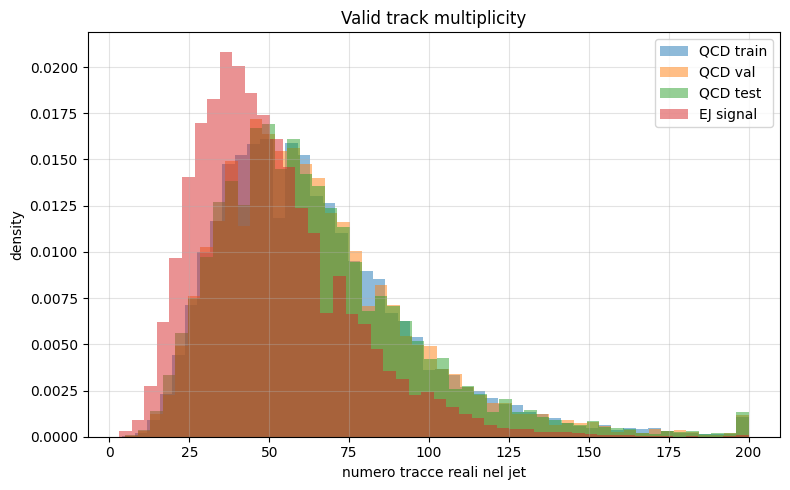

In [ ]:
# Guardo quante tracce vere hanno i jet.
# È una diagnostica utile prima di addestrare il Transformer.
# Questo plot controlla una proprietà fisica semplice: la molteplicità di tracce.
# Se QCD e segnale hanno distribuzioni molto diverse, il modello potrebbe usare
# anche questa informazione. Non è necessariamente un problema, ma va saputo
# quando si interpreta l'anomaly score.


plt.figure(figsize=(8, 5))

plt.hist(mask_train.sum(axis=1), bins=50, alpha=0.5, density=True, label="QCD train")
plt.hist(mask_val.sum(axis=1), bins=50, alpha=0.5, density=True, label="QCD val")
plt.hist(mask_bkg_test.sum(axis=1), bins=50, alpha=0.5, density=True, label="QCD test")
plt.hist(mask_sig.sum(axis=1), bins=50, alpha=0.5, density=True, label="EJ signal")

plt.xlabel("numero tracce reali nel jet")
plt.ylabel("density")
plt.title("Valid track multiplicity")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()

plt.savefig(PLOTS_DIR / "valid_track_multiplicity.png", dpi=200)
plt.show()


## 8. Dataset e DataLoader

Qui definisco la classe `JetTrackSetDataset`, cioè il contenitore PyTorch che restituisce per ogni evento tre oggetti: feature globali del jet, feature delle tracce e mask.

Il `DataLoader` divide il dataset in batch. Uso `pin_memory=False` e `num_workers=0` per rendere il notebook più stabile su Windows e su GPU consumer, evitando alcuni errori CUDA o problemi di multiprocessing.

Prepara solo il modo in cui PyTorch li legge durante training e valutazione.

In [ ]:
# Dataset PyTorch e DataLoader.
# Ogni batch contiene jet features, track features e mask.
# Il Dataset non fa trasformazioni fisiche: converte solo gli array numpy in tensori.
# La separazione tra dati e modello rende più facile cambiare architettura
# senza dover riscrivere preprocessing e valutazione.

class JetTrackSetDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(np.asarray(X_jets, dtype=np.float32))
        self.X_tracks = torch.from_numpy(np.asarray(X_tracks, dtype=np.float32))
        self.mask = torch.from_numpy(np.asarray(mask)).bool()

    def __len__(self):
        return self.X_jets.shape[0]

    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]


def make_loader(X_jets, X_tracks, mask, batch_size, shuffle=False):
    return DataLoader(
        JetTrackSetDataset(X_jets, X_tracks, mask),
        batch_size=int(batch_size),
        shuffle=shuffle,
        num_workers=0,
        pin_memory=False,
        drop_last=False,
    )


## 9. Modello: Transformer Track Autoencoder

Questa è la cella centrale del notebook. Definisco un autoencoder basato su Transformer per dati di tipo set/sequence.

La parte encoder prende le feature delle tracce e le proietta in uno spazio di dimensione `d_model`. Poi il Transformer usa la self-attention per far comunicare tra loro le tracce dello stesso jet. La mask viene passata come `src_key_padding_mask`, quindi le tracce di padding vengono ignorate.

Dopo il Transformer faccio mean pooling e max pooling sulle sole tracce reali. Il mean pooling descrive il comportamento medio del jet, mentre il max pooling può catturare tracce particolarmente anomale. A queste informazioni aggiungo le feature globali del jet e ottengo un vettore latente.

Il decoder ricostruisce sia le feature globali del jet sia le feature delle tracce. L'anomaly score sarà l'errore di ricostruzione: se un Emerging Jet è diverso dai QCD visti in training, dovrebbe essere ricostruito peggio.

In [ ]:
# Definizione del Transformer Autoencoder.
# L'encoder comprime il jet, il decoder prova a ricostruirlo.
# Struttura della rete:
# - track_embed porta ogni traccia nello spazio d_model;
# - TransformerEncoder fa self-attention tra le tracce dello stesso jet;
# - mean pooling riassume il comportamento medio;
# - max pooling conserva risposte estreme, utili per tracce displaced;
# - jet_encoder aggiunge informazione globale del jet;
# - to_latent produce la rappresentazione compressa;
# - track_decoder e jet_decoder ricostruiscono input originali.


class TransformerTrackAutoencoder(nn.Module):
    """
    Autoencoder set-based per jet.

    Il Transformer lavora sulle tracce. La mask indica quali tracce sono reali.
    L'encoder produce un embedding per ogni traccia e una rappresentazione globale del jet.
    Il decoder ricostruisce sia le feature globali del jet sia le feature delle tracce.
    """

    def __init__(
        self,
        n_track_features,
        n_jet_features,
        d_model=128,
        n_heads=4,
        n_layers=3,
        dim_feedforward=512,
        latent_dim=64,
        dropout=0.05,
    ):
        super().__init__()

        self.n_track_features = int(n_track_features)
        self.n_jet_features = int(n_jet_features)
        self.d_model = int(d_model)
        self.latent_dim = int(latent_dim)

        self.track_embed = nn.Sequential(
            nn.Linear(n_track_features, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        if n_jet_features > 0:
            self.jet_encoder = nn.Sequential(
                nn.Linear(n_jet_features, d_model),
                nn.LayerNorm(d_model),
                nn.GELU(),
                nn.Dropout(dropout),
            )
            pooled_dim = 3 * d_model
        else:
            self.jet_encoder = None
            pooled_dim = 2 * d_model

        self.to_latent = nn.Sequential(
            nn.Linear(pooled_dim, 2 * d_model),
            nn.LayerNorm(2 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2 * d_model, latent_dim),
        )

        self.latent_to_context = nn.Sequential(
            nn.Linear(latent_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        if n_jet_features > 0:
            self.jet_decoder = nn.Sequential(
                nn.Linear(latent_dim, d_model),
                nn.LayerNorm(d_model),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model, n_jet_features),
            )
        else:
            self.jet_decoder = None

        self.track_decoder = nn.Sequential(
            nn.Linear(2 * d_model, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Linear(d_model, n_track_features),
        )

    def encode(self, x_jets, x_tracks, mask):
        h = self.track_embed(x_tracks)

        # True nella padding mask significa "ignora questa posizione".
        h = self.transformer(
            h,
            src_key_padding_mask=~mask,
        )

        mask_f = mask.unsqueeze(-1).float()
        valid_counts = mask_f.sum(dim=1).clamp_min(1.0)

        mean_pool = (h * mask_f).sum(dim=1) / valid_counts

        h_for_max = h.masked_fill(~mask.unsqueeze(-1), -1e9)
        max_pool = h_for_max.max(dim=1).values
        max_pool = torch.where(
            torch.isfinite(max_pool),
            max_pool,
            torch.zeros_like(max_pool),
        )

        pooled = [mean_pool, max_pool]

        if self.jet_encoder is not None:
            pooled.append(self.jet_encoder(x_jets))

        z = self.to_latent(torch.cat(pooled, dim=1))

        return z, h

    def forward(self, x_jets, x_tracks, mask):
        z, h = self.encode(x_jets, x_tracks, mask)

        context = self.latent_to_context(z)
        context_expanded = context.unsqueeze(1).expand(-1, h.shape[1], -1)

        track_reco = self.track_decoder(
            torch.cat([h, context_expanded], dim=-1)
        )

        if self.jet_decoder is not None:
            jet_reco = self.jet_decoder(z)
        else:
            jet_reco = torch.zeros_like(x_jets)

        # Il padding resta a zero anche in output.
        track_reco = track_reco * mask.unsqueeze(-1).float()

        return jet_reco, track_reco, z


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 10. Loss, denoising e score

In questa cella definisco come viene addestrato e valutato l'autoencoder.

La funzione `apply_denoising` aggiunge un piccolo rumore alle feature in input durante il training. Il target resta l'evento pulito. Questa tecnica costringe il modello a imparare strutture robuste del QCD, non solo una copia esatta dell'input.

La loss è composta da due parti: errore di ricostruzione delle tracce e errore di ricostruzione delle feature globali del jet. L'errore sulle tracce è mascherato, quindi il padding non contribuisce. Lo score finale per evento è una combinazione tra track reconstruction error e jet reconstruction error.

In [ ]:
# Definizione della loss di ricostruzione e dello score.
# La loss sulle tracce usa la mask, quindi il padding non conta.
# La loss è costruita per rispettare il formato fisico dei dati.
# Per le tracce divido per il numero di tracce reali, così un jet con più tracce
# non ottiene automaticamente score più alto solo perché ha più termini nella somma.
# Il denoising rende il modello meno banale: deve ricostruire il jet pulito
# partendo da una versione leggermente disturbata.

def apply_denoising(x_jets, x_tracks, mask, noise_std=0.03, feature_drop_prob=0.03):
    """
    Aggiungo rumore solo durante il training.
    Il target resta l'input pulito: questa è la logica del denoising autoencoder.
    """

    if noise_std <= 0 and feature_drop_prob <= 0:
        return x_jets, x_tracks

    mask_f = mask.unsqueeze(-1).float()

    x_tracks_noisy = x_tracks

    if noise_std > 0:
        x_tracks_noisy = x_tracks_noisy + noise_std * torch.randn_like(x_tracks_noisy) * mask_f

    if feature_drop_prob > 0:
        keep = (torch.rand_like(x_tracks_noisy) > feature_drop_prob).float()
        x_tracks_noisy = x_tracks_noisy * keep * mask_f

    x_jets_noisy = x_jets

    if noise_std > 0:
        x_jets_noisy = x_jets_noisy + noise_std * torch.randn_like(x_jets_noisy)

    return x_jets_noisy, x_tracks_noisy


def reconstruction_loss(
    jet_reco,
    track_reco,
    x_jets,
    x_tracks,
    mask,
    jet_weight=0.5,
):
    mask_f = mask.unsqueeze(-1).float()

    track_sq = (track_reco - x_tracks) ** 2
    track_loss = (track_sq * mask_f).sum() / (mask_f.sum() * x_tracks.shape[-1]).clamp_min(1.0)

    if x_jets.shape[-1] > 0:
        jet_loss = torch.mean((jet_reco - x_jets) ** 2)
    else:
        jet_loss = torch.tensor(0.0, device=x_tracks.device)

    total = track_loss + jet_weight * jet_loss

    return total, track_loss, jet_loss


@torch.no_grad()
def compute_event_scores(
    model,
    X_jets,
    X_tracks,
    mask,
    batch_size=256,
    jet_weight=0.5,
):
    loader = make_loader(
        X_jets,
        X_tracks,
        mask,
        batch_size=batch_size,
        shuffle=False,
    )

    model.eval()

    total_scores = []
    track_scores = []
    jet_scores = []
    latents = []

    for x_jets, x_tracks, m in loader:
        x_jets = x_jets.to(device)
        x_tracks = x_tracks.to(device)
        m = m.to(device)

        jet_reco, track_reco, z = model(x_jets, x_tracks, m)

        mask_f = m.unsqueeze(-1).float()

        track_sq = (track_reco - x_tracks) ** 2
        track_event = (track_sq * mask_f).sum(dim=(1, 2)) / (
            mask_f.sum(dim=(1, 2)) * x_tracks.shape[-1]
        ).clamp_min(1.0)

        if x_jets.shape[-1] > 0:
            jet_event = torch.mean((jet_reco - x_jets) ** 2, dim=1)
        else:
            jet_event = torch.zeros_like(track_event)

        total_event = track_event + jet_weight * jet_event

        total_scores.append(total_event.detach().cpu().numpy())
        track_scores.append(track_event.detach().cpu().numpy())
        jet_scores.append(jet_event.detach().cpu().numpy())
        latents.append(z.detach().cpu().numpy())

    return {
        "total": np.concatenate(total_scores),
        "track": np.concatenate(track_scores),
        "jet": np.concatenate(jet_scores),
        "z": np.concatenate(latents, axis=0),
    }


@torch.no_grad()
def evaluate_reco_loss(model, loader, jet_weight=0.5):
    model.eval()

    total_loss = 0.0
    total_track = 0.0
    total_jet = 0.0
    total_items = 0

    for x_jets, x_tracks, mask in loader:
        x_jets = x_jets.to(device)
        x_tracks = x_tracks.to(device)
        mask = mask.to(device)

        jet_reco, track_reco, _ = model(x_jets, x_tracks, mask)

        loss, track_loss, jet_loss = reconstruction_loss(
            jet_reco,
            track_reco,
            x_jets,
            x_tracks,
            mask,
            jet_weight=jet_weight,
        )

        bs = x_jets.shape[0]
        total_loss += loss.item() * bs
        total_track += track_loss.item() * bs
        total_jet += jet_loss.item() * bs
        total_items += bs

    return {
        "loss": total_loss / max(total_items, 1),
        "track_loss": total_track / max(total_items, 1),
        "jet_loss": total_jet / max(total_items, 1),
    }


## 11. Hyperparameter tuning QCD-only

Esegue un tuning rapido degli iperparametri del Transformer Autoencoder. Il tuning usa solo QCD train e QCD validation: il segnale Emerging Jets non viene mai usato per scegliere la configurazione migliore.

Le configurazioni candidate modificano parametri come `d_model`, numero di attention heads, numero di layer Transformer, dimensione latente, dropout, learning rate, batch size e intensità del denoising.

La selezione viene fatta minimizzando la reconstruction loss su QCD validation, con una piccola penalità se c'è gap tra train e validation. In questo modo cerco una configurazione che ricostruisca bene il QCD senza overfittare troppo.

In [ ]:
# Tuning degli iperparametri usando solo QCD.
# Il segnale non viene usato per scegliere il modello.
# Nel tuning non uso mai gli Emerging Jets.
# Provo configurazioni con diversa capacità:
# - d_model e dim_feedforward controllano la larghezza della rete;
# - n_layers controlla la profondità del Transformer;
# - latent_dim controlla quanto è compresso il jet;
# - noise_std e feature_drop_prob controllano il denoising;
# - jet_weight bilancia informazione globale del jet e informazione delle tracce.
# La selection_score è QCD-only, quindi resta coerente con l'impostazione unsupervised.

# ============================================================
# Tuning dell'autoencoder
# ============================================================
# Uso solo QCD train e QCD validation.
# Il segnale EJ non entra mai nella scelta degli iperparametri.
# ============================================================

CANDIDATE_CONFIGS = [
    {
        "d_model": 96,
        "n_heads": 4,
        "n_layers": 2,
        "dim_feedforward": 384,
        "latent_dim": 32,
        "dropout": 0.05,
        "lr": 1.0e-4,
        "weight_decay": 1e-5,
        "batch_size": 128,
        "noise_std": 0.02,
        "feature_drop_prob": 0.02,
        "jet_weight": 0.50,
    },
    {
        "d_model": 128,
        "n_heads": 4,
        "n_layers": 3,
        "dim_feedforward": 512,
        "latent_dim": 64,
        "dropout": 0.05,
        "lr": 8.0e-5,
        "weight_decay": 2e-5,
        "batch_size": 96,
        "noise_std": 0.03,
        "feature_drop_prob": 0.03,
        "jet_weight": 0.50,
    },
    {
        "d_model": 128,
        "n_heads": 8,
        "n_layers": 3,
        "dim_feedforward": 512,
        "latent_dim": 64,
        "dropout": 0.07,
        "lr": 7.0e-5,
        "weight_decay": 2e-5,
        "batch_size": 80,
        "noise_std": 0.03,
        "feature_drop_prob": 0.05,
        "jet_weight": 0.50,
    },
    {
        "d_model": 160,
        "n_heads": 8,
        "n_layers": 4,
        "dim_feedforward": 640,
        "latent_dim": 64,
        "dropout": 0.08,
        "lr": 5.0e-5,
        "weight_decay": 3e-5,
        "batch_size": 64,
        "noise_std": 0.04,
        "feature_drop_prob": 0.05,
        "jet_weight": 0.50,
    },
    {
        "d_model": 192,
        "n_heads": 8,
        "n_layers": 4,
        "dim_feedforward": 768,
        "latent_dim": 96,
        "dropout": 0.10,
        "lr": 4.0e-5,
        "weight_decay": 5e-5,
        "batch_size": 48,
        "noise_std": 0.04,
        "feature_drop_prob": 0.05,
        "jet_weight": 0.75,
    },
]

FALLBACK_CONFIG = {
    "d_model": 128,
    "n_heads": 4,
    "n_layers": 3,
    "dim_feedforward": 512,
    "latent_dim": 64,
    "dropout": 0.05,
    "lr": 8.0e-5,
    "weight_decay": 2e-5,
    "batch_size": 96,
    "noise_std": 0.03,
    "feature_drop_prob": 0.03,
    "jet_weight": 0.50,
}


def subsample_triplet(Xj, Xt, M, max_n, seed):
    if max_n is None or len(Xj) <= max_n:
        return Xj, Xt, M

    rr = np.random.default_rng(seed)
    idx = rr.choice(len(Xj), size=max_n, replace=False)

    return Xj[idx], Xt[idx], M[idx]


Xj_tune_train, Xt_tune_train, M_tune_train = subsample_triplet(
    X_jets_train,
    X_tracks_train,
    mask_train,
    TUNE_MAX_TRAIN,
    SEED,
)

Xj_tune_val, Xt_tune_val, M_tune_val = subsample_triplet(
    X_jets_val,
    X_tracks_val,
    mask_val,
    TUNE_MAX_VAL,
    SEED + 1,
)

print("Tuning train:", Xj_tune_train.shape, Xt_tune_train.shape)
print("Tuning val  :", Xj_tune_val.shape, Xt_tune_val.shape)


def train_one_epoch_ae(model, loader, optimizer, cfg):
    model.train()

    losses = []
    track_losses = []
    jet_losses = []

    for x_jets, x_tracks, mask in loader:
        x_jets = x_jets.to(device)
        x_tracks = x_tracks.to(device)
        mask = mask.to(device)

        optimizer.zero_grad(set_to_none=True)

        if USE_DENOISING:
            x_jets_in, x_tracks_in = apply_denoising(
                x_jets,
                x_tracks,
                mask,
                noise_std=float(cfg["noise_std"]),
                feature_drop_prob=float(cfg["feature_drop_prob"]),
            )
        else:
            x_jets_in, x_tracks_in = x_jets, x_tracks

        jet_reco, track_reco, _ = model(x_jets_in, x_tracks_in, mask)

        loss, track_loss, jet_loss = reconstruction_loss(
            jet_reco,
            track_reco,
            x_jets,
            x_tracks,
            mask,
            jet_weight=float(cfg["jet_weight"]),
        )

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita durante il training AE.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        losses.append(loss.item())
        track_losses.append(track_loss.item())
        jet_losses.append(jet_loss.item())

    return {
        "loss": float(np.mean(losses)),
        "track_loss": float(np.mean(track_losses)),
        "jet_loss": float(np.mean(jet_losses)),
    }


def tune_one_config(cfg, config_id):
    print("\n" + "=" * 90)
    print(f"AE CONFIG {config_id}/{len(CANDIDATE_CONFIGS)}")
    print(cfg)

    batch_size = int(min(int(cfg["batch_size"]), TUNE_BATCH_CAP))

    train_loader_tune = make_loader(
        Xj_tune_train,
        Xt_tune_train,
        M_tune_train,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader_tune = make_loader(
        Xj_tune_val,
        Xt_tune_val,
        M_tune_val,
        batch_size=batch_size,
        shuffle=False,
    )

    model_tune = TransformerTrackAutoencoder(
        n_track_features=n_track_features,
        n_jet_features=n_jet_features,
        d_model=int(cfg["d_model"]),
        n_heads=int(cfg["n_heads"]),
        n_layers=int(cfg["n_layers"]),
        dim_feedforward=int(cfg["dim_feedforward"]),
        latent_dim=int(cfg["latent_dim"]),
        dropout=float(cfg["dropout"]),
    ).to(device)

    optimizer_tune = torch.optim.AdamW(
        model_tune.parameters(),
        lr=float(cfg["lr"]),
        weight_decay=float(cfg["weight_decay"]),
    )

    scheduler_tune = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_tune,
        mode="min",
        factor=0.5,
        patience=2,
    )

    best_val = np.inf
    best_state = None
    best_epoch = -1
    epochs_without_improvement = 0

    for epoch in range(1, TUNE_EPOCHS + 1):
        train_metrics = train_one_epoch_ae(
            model_tune,
            train_loader_tune,
            optimizer_tune,
            cfg,
        )

        val_metrics = evaluate_reco_loss(
            model_tune,
            val_loader_tune,
            jet_weight=float(cfg["jet_weight"]),
        )

        scheduler_tune.step(val_metrics["loss"])

        print(
            f"epoch {epoch:02d}/{TUNE_EPOCHS} | "
            f"train={train_metrics['loss']:.6f} | "
            f"val={val_metrics['loss']:.6f} | "
            f"track={val_metrics['track_loss']:.6f} | "
            f"jet={val_metrics['jet_loss']:.6f}"
        )

        if val_metrics["loss"] < best_val:
            best_val = val_metrics["loss"]
            best_epoch = epoch
            best_state = copy.deepcopy(model_tune.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= TUNE_PATIENCE:
            print("early stopping tuning")
            break

    if best_state is not None:
        model_tune.load_state_dict(best_state)

    train_final = evaluate_reco_loss(
        model_tune,
        train_loader_tune,
        jet_weight=float(cfg["jet_weight"]),
    )

    val_final = evaluate_reco_loss(
        model_tune,
        val_loader_tune,
        jet_weight=float(cfg["jet_weight"]),
    )

    gap = max(0.0, val_final["loss"] - train_final["loss"])

    # Selection QCD-only: loss di validazione bassa, ma senza premiare overfitting.
    selection_score = val_final["loss"] + 0.30 * gap

    row = {
        "config_id": int(config_id),
        **cfg,
        "batch_size": int(batch_size),
        "n_params": int(count_params(model_tune)),
        "best_epoch": int(best_epoch),
        "train_loss": float(train_final["loss"]),
        "train_track_loss": float(train_final["track_loss"]),
        "train_jet_loss": float(train_final["jet_loss"]),
        "val_loss": float(val_final["loss"]),
        "val_track_loss": float(val_final["track_loss"]),
        "val_jet_loss": float(val_final["jet_loss"]),
        "generalization_gap": float(gap),
        "selection_score": float(selection_score),
    }

    del model_tune
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return row


if RUN_HPARAM_TUNING:
    tuning_rows = []

    for i, cfg in enumerate(CANDIDATE_CONFIGS, start=1):
        try:
            tuning_rows.append(tune_one_config(cfg, i))

        except RuntimeError as e:
            msg = str(e).lower()

            if "cuda" in msg or "out of memory" in msg:
                print("[CUDA ERROR] Riavvia il kernel e riduci batch_size/TUNE_BATCH_CAP.")
                raise

            print(f"[SKIP CONFIG {i}] RuntimeError: {e}")

        except Exception as e:
            print(f"[SKIP CONFIG {i}] {type(e).__name__}: {e}")

        finally:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    tuning_results_df = pd.DataFrame(tuning_rows)

    if tuning_results_df.empty or "selection_score" not in tuning_results_df.columns:
        print("[WARN] Nessun risultato valido nel tuning. Uso fallback.")
        BEST_CONFIG = FALLBACK_CONFIG.copy()

    else:
        tuning_results_df = (
            tuning_results_df
            .sort_values("selection_score", ascending=True)
            .reset_index(drop=True)
        )

        display(tuning_results_df)

        tuning_results_df.to_csv(
            OUTPUT_DIR / "transformer_track_autoencoder_hparam_tuning.csv",
            index=False,
        )

        print("Saved:", OUTPUT_DIR / "transformer_track_autoencoder_hparam_tuning.csv")

        BEST_CONFIG = tuning_results_df.iloc[0].to_dict()

else:
    tuning_results_df = pd.DataFrame()
    BEST_CONFIG = FALLBACK_CONFIG.copy()

print("\nBEST_CONFIG:")
print(BEST_CONFIG)


Tuning train: (12000, 15) (12000, 200, 16)
Tuning val  : (6000, 15) (6000, 200, 16)

AE CONFIG 1/5
{'d_model': 96, 'n_heads': 4, 'n_layers': 2, 'dim_feedforward': 384, 'latent_dim': 32, 'dropout': 0.05, 'lr': 0.0001, 'weight_decay': 1e-05, 'batch_size': 128, 'noise_std': 0.02, 'feature_drop_prob': 0.02, 'jet_weight': 0.5}
epoch 01/10 | train=0.907358 | val=0.514100 | track=0.368669 | jet=0.290861
epoch 02/10 | train=0.450456 | val=0.295903 | track=0.212281 | jet=0.167242
epoch 03/10 | train=0.306195 | val=0.202041 | track=0.143676 | jet=0.116731
epoch 04/10 | train=0.235034 | val=0.150269 | track=0.106603 | jet=0.087333
epoch 05/10 | train=0.192916 | val=0.117114 | track=0.082743 | jet=0.068743
epoch 06/10 | train=0.163691 | val=0.093873 | track=0.066065 | jet=0.055614
epoch 07/10 | train=0.142851 | val=0.076995 | track=0.053837 | jet=0.046315
epoch 08/10 | train=0.127152 | val=0.064330 | track=0.044680 | jet=0.039300
epoch 09/10 | train=0.114442 | val=0.054856 | track=0.037859 | jet=0

,config_id,d_model,n_heads,n_layers,dim_feedforward,latent_dim,dropout,lr,weight_decay,batch_size,...,n_params,best_epoch,train_loss,train_track_loss,train_jet_loss,val_loss,val_track_loss,val_jet_loss,generalization_gap,selection_score
0,4,160,8,4,640,64,0.08,0.00005,0.00003,64,...,1548415,10,0.028165,0.017798,0.020734,0.027061,0.017624,0.018875,0.0,0.027061
1,5,192,8,4,768,96,0.10,0.00004,0.00005,48,...,2239039,10,0.029514,0.015880,0.018180,0.028149,0.015737,0.016549,0.0,0.028149
2,2,128,4,3,512,64,0.05,0.00008,0.00002,96,...,802911,10,0.029730,0.018421,0.022617,0.028371,0.018186,0.020370,0.0,0.028371
3,3,128,8,3,512,64,0.07,0.00007,0.00002,80,...,802911,10,0.032021,0.020714,0.022614,0.030586,0.020488,0.020196,0.0,0.030586
4,1,96,4,2,384,32,0.05,0.00010,0.00001,128,...,336735,10,0.050075,0.032917,0.034315,0.047928,0.032475,0.030906,0.0,0.047928


Saved: ..\outputs\transformer_track_autoencoder\transformer_track_autoencoder_hparam_tuning.csv

BEST_CONFIG:
{'config_id': 4.0, 'd_model': 160.0, 'n_heads': 8.0, 'n_layers': 4.0, 'dim_feedforward': 640.0, 'latent_dim': 64.0, 'dropout': 0.08, 'lr': 5e-05, 'weight_decay': 3e-05, 'batch_size': 64.0, 'noise_std': 0.04, 'feature_drop_prob': 0.05, 'jet_weight': 0.5, 'n_params': 1548415.0, 'best_epoch': 10.0, 'train_loss': 0.028164702450235685, 'train_track_loss': 0.01779785378774007, 'train_jet_loss': 0.020733697081605593, 'val_loss': 0.027060913026332855, 'val_track_loss': 0.017623624213039875, 'val_jet_loss': 0.018874577780564627, 'generalization_gap': 0.0, 'selection_score': 0.027060913026332855}


## 12. Plot del tuning

Visualizza i risultati del tuning. Per ogni iperparametro viene mostrato il miglior valore di `selection_score` ottenuto tra le configurazioni provate.

Il grafico è utile per capire quali parametri influenzano di più la qualità del modello. Per esempio, si può vedere se il modello preferisce pochi layer o tanti layer, una dimensione latente piccola o grande, oppure più o meno rumore nel denoising.

Questi plot non usano il segnale: sono ancora una diagnostica QCD-only.

,config_id,d_model,n_heads,n_layers,dim_feedforward,latent_dim,dropout,lr,weight_decay,batch_size,...,n_params,best_epoch,train_loss,train_track_loss,train_jet_loss,val_loss,val_track_loss,val_jet_loss,generalization_gap,selection_score
0,4,160,8,4,640,64,0.08,0.00005,0.00003,64,...,1548415,10,0.028165,0.017798,0.020734,0.027061,0.017624,0.018875,0.0,0.027061
1,5,192,8,4,768,96,0.10,0.00004,0.00005,48,...,2239039,10,0.029514,0.015880,0.018180,0.028149,0.015737,0.016549,0.0,0.028149
2,2,128,4,3,512,64,0.05,0.00008,0.00002,96,...,802911,10,0.029730,0.018421,0.022617,0.028371,0.018186,0.020370,0.0,0.028371
3,3,128,8,3,512,64,0.07,0.00007,0.00002,80,...,802911,10,0.032021,0.020714,0.022614,0.030586,0.020488,0.020196,0.0,0.030586
4,1,96,4,2,384,32,0.05,0.00010,0.00001,128,...,336735,10,0.050075,0.032917,0.034315,0.047928,0.032475,0.030906,0.0,0.047928


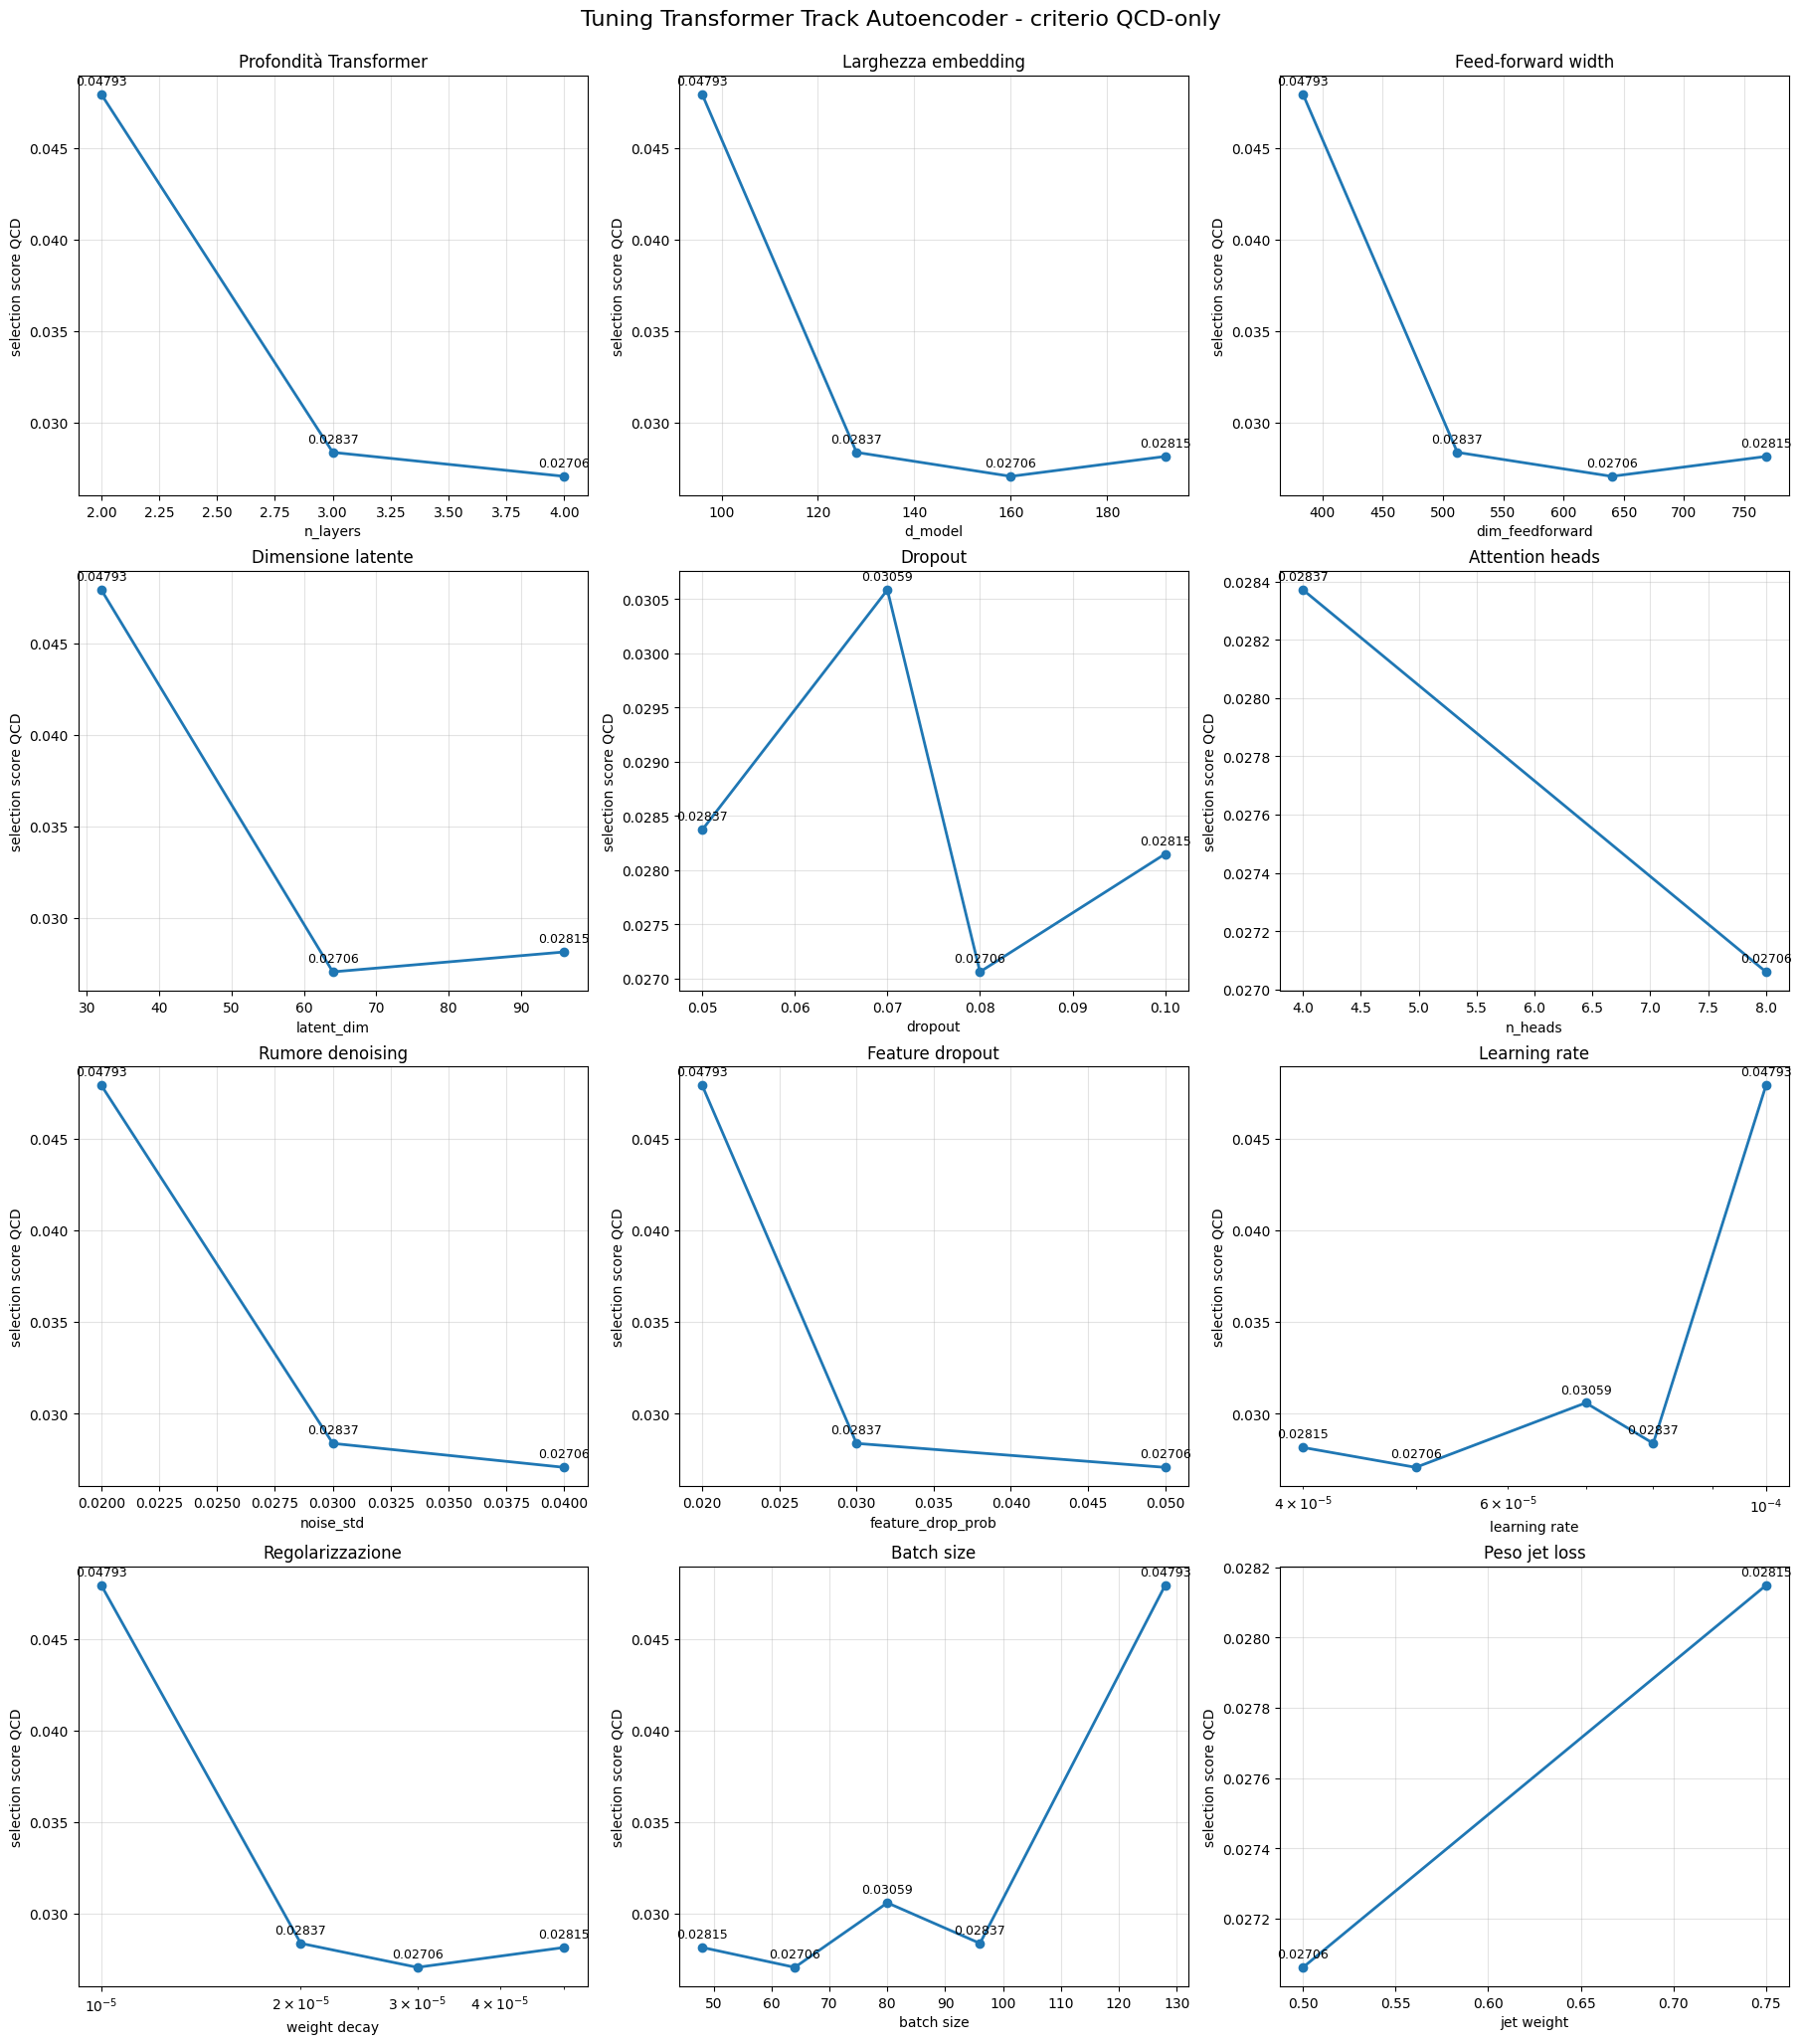

Salvato: ..\outputs\transformer_track_autoencoder\plots\transformer_track_autoencoder_hparam_elbow_plots.png


In [ ]:
# Plot del tuning.
# Mi aiutano a vedere quali iperparametri funzionano meglio.
# Questi grafici non scelgono il modello da soli, ma aiutano a leggere il tuning.
# Se un parametro mostra un chiaro minimo, posso giustificare meglio la scelta finale.
# Se invece i punti sono simili, significa che il modello è poco sensibile a quel parametro.

Y_COL = "selection_score"
Y_LABEL = "selection score QCD"

if tuning_results_df.empty or Y_COL not in tuning_results_df.columns:
    print("[SKIP] Nessun risultato di tuning da plottare.")
    display(pd.DataFrame([BEST_CONFIG]))

else:
    display(tuning_results_df.sort_values(Y_COL).reset_index(drop=True))

    def best_by_param(data, param):
        return (
            data
            .dropna(subset=[param, Y_COL])
            .groupby(param, as_index=False)[Y_COL]
            .min()
            .sort_values(param)
            .reset_index(drop=True)
        )

    def plot_line_with_labels(ax, x, y, xlabel, title, logx=False):
        ax.plot(x, y, marker="o", linewidth=2)

        for xi, yi in zip(x, y):
            ax.annotate(
                f"{yi:.5f}",
                xy=(xi, yi),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center",
                fontsize=9,
            )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(Y_LABEL)
        ax.set_title(title)
        ax.grid(True, alpha=0.35)

        if logx:
            ax.set_xscale("log")

    plot_specs = [
        ("n_layers", "n_layers", "Profondità Transformer", False),
        ("d_model", "d_model", "Larghezza embedding", False),
        ("dim_feedforward", "dim_feedforward", "Feed-forward width", False),
        ("latent_dim", "latent_dim", "Dimensione latente", False),
        ("dropout", "dropout", "Dropout", False),
        ("n_heads", "n_heads", "Attention heads", False),
        ("noise_std", "noise_std", "Rumore denoising", False),
        ("feature_drop_prob", "feature_drop_prob", "Feature dropout", False),
        ("lr", "learning rate", "Learning rate", True),
        ("weight_decay", "weight decay", "Regolarizzazione", True),
        ("batch_size", "batch size", "Batch size", False),
        ("jet_weight", "jet weight", "Peso jet loss", False),
    ]

    plot_specs = [spec for spec in plot_specs if spec[0] in tuning_results_df.columns]

    ncols = 3
    nrows = math.ceil(len(plot_specs) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(18, 5 * nrows),
        constrained_layout=True,
    )

    axes = np.array(axes).reshape(-1)

    fig.suptitle(
        "Tuning Transformer Track Autoencoder - criterio QCD-only",
        fontsize=16,
        y=1.02,
    )

    for ax, (param, xlabel, title, logx) in zip(axes, plot_specs):
        g = best_by_param(tuning_results_df, param)

        if g.empty:
            ax.axis("off")
            continue

        plot_line_with_labels(
            ax,
            g[param],
            g[Y_COL],
            xlabel,
            title,
            logx=logx,
        )

    for ax in axes[len(plot_specs):]:
        ax.axis("off")

    out_path = PLOTS_DIR / "transformer_track_autoencoder_hparam_elbow_plots.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Salvato:", out_path)


## 13. Creazione del modello finale

Dopo il tuning, questa cella costruisce il modello finale usando la configurazione migliore trovata. Se il tuning è disattivato o fallisce, viene usata una configurazione fallback.

Qui vengono impostati anche learning rate, weight decay, batch size, rumore di denoising e peso della jet loss. Poi creo i DataLoader finali per train e validation e inizializzo ottimizzatore e scheduler.

Lo scheduler riduce il learning rate quando la validation loss smette di migliorare. Questo aiuta la convergenza nelle ultime epoche.

In [ ]:
# Creo il modello finale usando la configurazione migliore.
# Qui preparo anche optimizer, scheduler e DataLoader finali.
# Qui passo dal tuning al modello finale.
# Tutti gli iperparametri vengono letti da BEST_CONFIG, così il training finale
# usa esattamente la configurazione selezionata.
# Il batch size viene comunque limitato dal cap per evitare problemi di memoria GPU.


D_MODEL = int(BEST_CONFIG["d_model"])
N_HEADS = int(BEST_CONFIG["n_heads"])
N_LAYERS = int(BEST_CONFIG["n_layers"])
DIM_FEEDFORWARD = int(BEST_CONFIG["dim_feedforward"])
LATENT_DIM = int(BEST_CONFIG["latent_dim"])
DROPOUT = float(BEST_CONFIG["dropout"])

LR = float(BEST_CONFIG["lr"])
WEIGHT_DECAY = float(BEST_CONFIG["weight_decay"])
BATCH_SIZE = int(min(int(BEST_CONFIG["batch_size"]), FINAL_BATCH_CAP))

NOISE_STD = float(BEST_CONFIG.get("noise_std", 0.03))
FEATURE_DROP_PROB = float(BEST_CONFIG.get("feature_drop_prob", 0.03))
JET_SCORE_WEIGHT = float(BEST_CONFIG.get("jet_weight", JET_SCORE_WEIGHT))

train_loader = make_loader(
    X_jets_train,
    X_tracks_train,
    mask_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = make_loader(
    X_jets_val,
    X_tracks_val,
    mask_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

model = TransformerTrackAutoencoder(
    n_track_features=n_track_features,
    n_jet_features=n_jet_features,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    latent_dim=LATENT_DIM,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

print(model)
print("Parameters:", count_params(model))
print()
print("Final config:")
print("D_MODEL        =", D_MODEL)
print("N_HEADS        =", N_HEADS)
print("N_LAYERS       =", N_LAYERS)
print("DIM_FEEDFORWARD=", DIM_FEEDFORWARD)
print("LATENT_DIM     =", LATENT_DIM)
print("DROPOUT        =", DROPOUT)
print("LR             =", LR)
print("WEIGHT_DECAY   =", WEIGHT_DECAY)
print("BATCH_SIZE     =", BATCH_SIZE)
print("NOISE_STD      =", NOISE_STD)
print("FEATURE_DROP   =", FEATURE_DROP_PROB)
print("JET_SCORE_WEIGHT =", JET_SCORE_WEIGHT)


TransformerTrackAutoencoder(
  (track_embed): Sequential(
    (0): Linear(in_features=16, out_features=160, bias=True)
    (1): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.08, inplace=False)
    (4): Linear(in_features=160, out_features=160, bias=True)
    (5): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=160, out_features=160, bias=True)
        )
        (linear1): Linear(in_features=160, out_features=640, bias=True)
        (dropout): Dropout(p=0.08, inplace=False)
        (linear2): Linear(in_features=640, out_features=160, bias=True)
        (norm1): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((160,), eps=1e-05, elementwise_af


La configurazione stampata qui definisce il modello effettivamente addestrato nel run finale. I parametri più importanti sono:

- `d_model`: dimensione interna delle tracce dopo embedding;
- `n_layers`: profondità del Transformer;
- `latent_dim`: dimensione della rappresentazione compressa del jet;
- `NOISE_STD` e `FEATURE_DROP`: intensità del denoising;
- `JET_SCORE_WEIGHT`: peso dato alla ricostruzione delle feature globali del jet.

Fisicamente, la parte track è la più importante per Emerging Jets, ma le feature globali del jet possono comunque aiutare perché contengono informazioni sulla struttura complessiva del getto.

## 14. Training finale

Addestra il Transformer Autoencoder solo sui jet QCD di training. A ogni epoca il modello riceve QCD eventualmente rumorosi e deve ricostruire gli input puliti.

Dopo ogni epoca calcolo la loss su QCD validation. Se la validation loss migliora, salvo una copia dei pesi del modello. Se non migliora per troppe epoche consecutive, l'early stopping interrompe il training.

Questa scelta serve a evitare overfitting: voglio un modello che impari la struttura generale del QCD, non che memorizzi il training set.

In [ ]:
# Training finale QCD-only.
# Salvo il modello migliore in base alla validation loss.
# In ogni epoca il modello vede solo QCD.
# Il segnale non entra nel training: viene tenuto fuori fino alla valutazione.
# L'early stopping prende il modello con validation loss più bassa,
# cioè quello che ricostruisce meglio QCD non visto in training.

train_history = []
val_history = []

best_val_loss = np.inf
best_epoch = -1
best_state_dict = None
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(1, N_EPOCHS_FINAL + 1):
    cfg_epoch = {
        "noise_std": NOISE_STD,
        "feature_drop_prob": FEATURE_DROP_PROB,
        "jet_weight": JET_SCORE_WEIGHT,
    }

    train_metrics = train_one_epoch_ae(
        model,
        train_loader,
        optimizer,
        cfg_epoch,
    )

    val_metrics = evaluate_reco_loss(
        model,
        val_loader,
        jet_weight=JET_SCORE_WEIGHT,
    )

    scheduler.step(val_metrics["loss"])

    train_history.append({
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        "lr": optimizer.param_groups[0]["lr"],
    })

    val_history.append({
        "epoch": epoch,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    })

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    elapsed_min = (time.time() - start_time) / 60.0

    print(
        f"Epoch {epoch:03d}/{N_EPOCHS_FINAL} | "
        f"train={train_metrics['loss']:.6f} | "
        f"val={val_metrics['loss']:.6f} | "
        f"track={val_metrics['track_loss']:.6f} | "
        f"jet={val_metrics['jet_loss']:.6f} | "
        f"best={best_val_loss:.6f} @ {best_epoch} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e} | "
        f"elapsed={elapsed_min:.1f} min"
    )

    if epochs_without_improvement >= PATIENCE_FINAL:
        print("Early stopping.")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"Loaded best model from epoch {best_epoch} with val loss={best_val_loss:.6f}")

df_train = pd.DataFrame(train_history)
df_val = pd.DataFrame(val_history)
df_history = pd.merge(df_train, df_val, on="epoch")

df_history.to_csv(
    OUTPUT_DIR / "transformer_track_autoencoder_training_history.csv",
    index=False,
)

print("Saved:", OUTPUT_DIR / "transformer_track_autoencoder_training_history.csv")


Epoch 001/100 | train=0.548459 | val=0.177686 | track=0.119236 | jet=0.116899 | best=0.177686 @ 1 | lr=5.00e-05 | elapsed=0.6 min
Epoch 002/100 | train=0.220580 | val=0.094577 | track=0.060804 | jet=0.067546 | best=0.094577 @ 2 | lr=5.00e-05 | elapsed=1.2 min
Epoch 003/100 | train=0.160726 | val=0.060637 | track=0.038458 | jet=0.044357 | best=0.060637 @ 3 | lr=5.00e-05 | elapsed=1.8 min
Epoch 004/100 | train=0.132225 | val=0.044097 | track=0.027563 | jet=0.033067 | best=0.044097 @ 4 | lr=5.00e-05 | elapsed=2.4 min
Epoch 005/100 | train=0.115861 | val=0.033825 | track=0.021477 | jet=0.024695 | best=0.033825 @ 5 | lr=5.00e-05 | elapsed=3.1 min
Epoch 006/100 | train=0.105101 | val=0.028182 | track=0.017898 | jet=0.020567 | best=0.028182 @ 6 | lr=5.00e-05 | elapsed=3.7 min
Epoch 007/100 | train=0.097971 | val=0.023468 | track=0.015245 | jet=0.016445 | best=0.023468 @ 7 | lr=5.00e-05 | elapsed=4.3 min
Epoch 008/100 | train=0.092132 | val=0.020534 | track=0.013421 | jet=0.014227 | best=0.020



Il valore più importante da osservare qui è la validation loss. Se diminuisce insieme alla train loss, il modello sta imparando una rappresentazione QCD generalizzabile.

L'early stopping seleziona il modello migliore su QCD validation. Questo è coerente con il setup non supervisionato: il segnale resta completamente escluso dal training. In questo caso non l'ha usata

## 15. Training plots
Produce i grafici della training history. Il primo plot confronta la reconstruction loss su train e validation. Se le due curve sono vicine, il modello sta generalizzando bene sul QCD.

Il secondo plot separa le componenti della validation loss: errore sulle tracce ed errore sulle feature globali del jet. Questo è utile per capire quale parte del dato è più difficile da ricostruire.

Nel contesto fisico, la parte track è particolarmente importante perché gli Emerging Jets differiscono dal QCD soprattutto per la struttura delle tracce e degli hit.

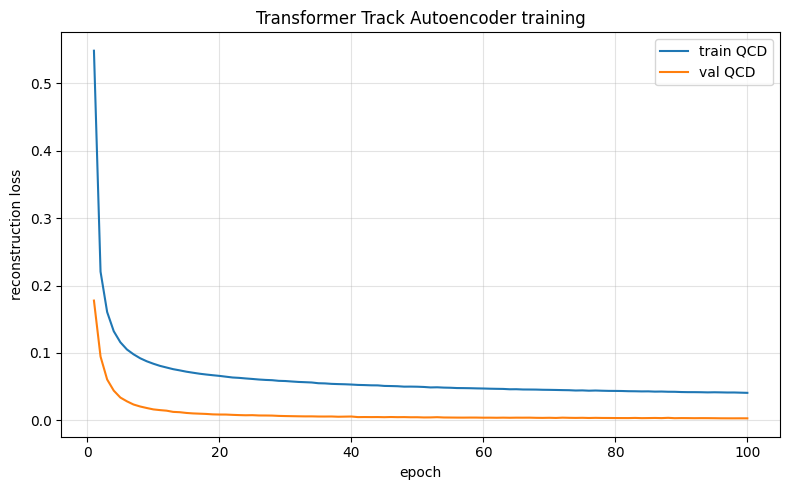

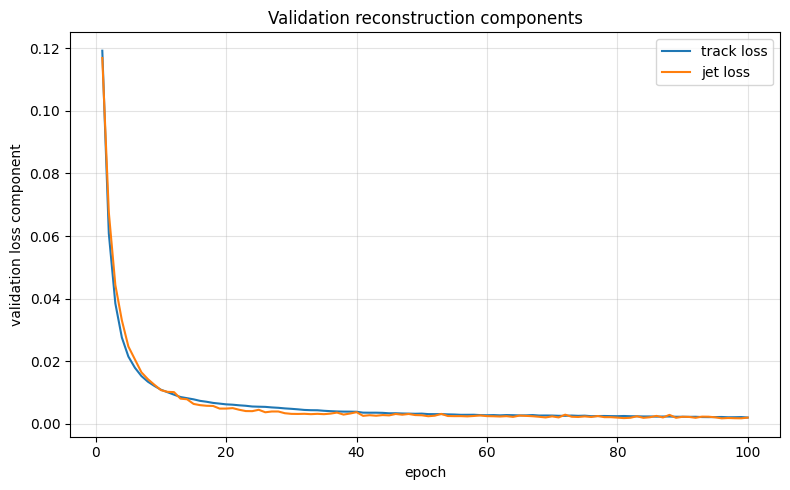

In [ ]:
# Grafici della loss di training.
# Servono per controllare convergenza e overfitting.
# Questi plot sono la prima diagnostica dopo il training.
# Se train loss scende ma val loss sale, sto overfittando.
# Se entrambe scendono e poi si stabilizzano, il training è ragionevole.
# Le componenti track/jet aiutano a capire dove il modello sta imparando meglio.

plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch"], df_history["train_loss"], label="train QCD")
plt.plot(df_history["epoch"], df_history["val_loss"], label="val QCD")
plt.xlabel("epoch")
plt.ylabel("reconstruction loss")
plt.title("Transformer Track Autoencoder training")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_track_autoencoder_training_loss.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch"], df_history["val_track_loss"], label="track loss")
plt.plot(df_history["epoch"], df_history["val_jet_loss"], label="jet loss")
plt.xlabel("epoch")
plt.ylabel("validation loss component")
plt.title("Validation reconstruction components")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_track_autoencoder_loss_components.png", dpi=200)
plt.show()



Questi grafici mostrano che il training è stabile.

La separazione tra track loss e jet loss aiuta a capire quale parte dell'input domina l'errore. Per questo problema ci si aspetta che le tracce abbiano un ruolo centrale, perché gli Emerging Jets sono caratterizzati proprio da pattern anomali nelle tracce, in questo caso peròsembra che l'autoencodere impari allo stesso modo da entrambi

## 16. Calcolo anomaly score
Calcola lo score di anomalia per tutti gli split: QCD train, QCD validation, QCD test e segnale Emerging Jets.

Lo score principale è l'errore di ricostruzione totale. Salvo anche le componenti separate track e jet, oltre agli embedding latenti. Gli embedding possono essere utili per diagnostiche successive, mentre lo score viene usato per ROC, AUC e SIC.

Un buon risultato atteso è che gli Emerging Jets abbiano in media score più alto del QCD test, perché sono meno simili ai pattern QCD imparati durante il training.

In [ ]:
# Calcolo gli anomaly score.
# Lo score è l'errore di ricostruzione dell'autoencoder.
# Ora trasformo la reconstruction loss in anomaly score per evento.
# Tengo separati score totale, score tracce e score jet per poter interpretare il risultato.
# Se il segnale ha score più alto del QCD test, il modello sta identificando anomalie rispetto al QCD.

scores_train_dict = compute_event_scores(
    model,
    X_jets_train,
    X_tracks_train,
    mask_train,
    batch_size=SCORE_BATCH_SIZE,
    jet_weight=JET_SCORE_WEIGHT,
)

scores_val_dict = compute_event_scores(
    model,
    X_jets_val,
    X_tracks_val,
    mask_val,
    batch_size=SCORE_BATCH_SIZE,
    jet_weight=JET_SCORE_WEIGHT,
)

scores_bkg_test_dict = compute_event_scores(
    model,
    X_jets_bkg_test,
    X_tracks_bkg_test,
    mask_bkg_test,
    batch_size=SCORE_BATCH_SIZE,
    jet_weight=JET_SCORE_WEIGHT,
)

scores_sig_dict = compute_event_scores(
    model,
    X_jets_sig,
    X_tracks_sig,
    mask_sig,
    batch_size=SCORE_BATCH_SIZE,
    jet_weight=JET_SCORE_WEIGHT,
)

scores_train = scores_train_dict["total"]
scores_val = scores_val_dict["total"]
scores_bkg_test = scores_bkg_test_dict["total"]
scores_sig = scores_sig_dict["total"]

Z_train = scores_train_dict["z"]
Z_val = scores_val_dict["z"]
Z_bkg_test = scores_bkg_test_dict["z"]
Z_sig = scores_sig_dict["z"]

for name, s in [
    ("train QCD", scores_train),
    ("val QCD", scores_val),
    ("test QCD", scores_bkg_test),
    ("signal EJ", scores_sig),
]:
    print(name, "mean", float(np.mean(s)), "std", float(np.std(s)), "q", np.percentile(s, [1, 50, 99]))


train QCD mean 0.0027450602501630783 std 0.0023692946415394545 q [0.00118616 0.00236586 0.01082057]
val QCD mean 0.00286755315028131 std 0.004537533037364483 q [0.00116523 0.00237012 0.01129247]
test QCD mean 0.0030438764952123165 std 0.007787421811372042 q [0.0011902  0.00237825 0.01202915]
signal EJ mean 0.00558024225756526 std 0.0063423942774534225 q [0.00176442 0.0042309  0.02304827]




Le medie e le deviazioni standard stampate qui sono un primo controllo prima della ROC. Se lo score del segnale è mediamente più alto del QCD test, l'autoencoder sta ricostruendo peggio gli Emerging Jets, cioè li considera più anomali.

## 17. ROC/AUC e metriche a mistag fissato

Valuta quantitativamente il modello. La ROC confronta QCD test e Emerging Jets: il QCD test rappresenta il background indipendente, mentre il segnale viene usato solo ora per la valutazione.

La funzione `orient_scores` controlla anche il verso dello score. In teoria gli eventi anomali dovrebbero avere score maggiore, ma per sicurezza viene calcolata anche l'AUC con score invertito.

Oltre all'AUC, calcolo l'efficienza del segnale a mistag QCD fissato, per esempio 10%, 1% e 0.1%. Queste metriche sono importanti in fisica delle particelle perché spesso interessa lavorare a bassa accettanza di background.

In [ ]:
# Calcolo ROC, AUC ed efficienze a mistag fissato.
# Qui uso il segnale solo per la valutazione finale.
# L'AUC misura quanto bene lo score ordina QCD e segnale.
# L'orientamento automatico serve solo come controllo tecnico:
# fisicamente mi aspetto che score più alto significhi evento più anomalo.
# Le efficienze a mistag fissato sono spesso più rilevanti dell'AUC globale
# perché in una ricerca si lavora in regioni di background molto ridotto.

def orient_scores(bg, sig):
    bg = np.asarray(bg, dtype=np.float64)
    sig = np.asarray(sig, dtype=np.float64)

    y = np.concatenate([
        np.zeros(len(bg), dtype=np.int64),
        np.ones(len(sig), dtype=np.int64),
    ])

    s = np.concatenate([bg, sig])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv

    return bg, sig, auc, False, auc, auc_inv


def evaluate_scores(bg, sig, model_name="Transformer Track Autoencoder", score_name="masked reconstruction error"):
    bg_o, sig_o, best_auc, flipped, auc, auc_inv = orient_scores(bg, sig)

    y = np.concatenate([
        np.zeros(len(bg_o), dtype=np.int64),
        np.ones(len(sig_o), dtype=np.int64),
    ])

    s = np.concatenate([bg_o, sig_o])

    fpr, tpr, thresholds = roc_curve(y, s)

    rows = []

    for mistag in MISTAG_POINTS:
        threshold = np.quantile(bg_o, 1.0 - mistag)
        eff = np.mean(sig_o >= threshold)
        actual_mistag = np.mean(bg_o >= threshold)

        rows.append({
            "model": model_name,
            "score": score_name,
            "auc": best_auc,
            "raw_auc": auc,
            "auc_inverted": auc_inv,
            "flipped": flipped,
            "mistag_target": mistag,
            "actual_mistag": actual_mistag,
            "signal_efficiency": eff,
            "threshold": threshold,
        })

    return {
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "best_auc": best_auc,
        "auc": auc,
        "auc_inverted": auc_inv,
        "flipped": flipped,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "eff_table": pd.DataFrame(rows),
    }


eval_main = evaluate_scores(scores_bkg_test, scores_sig)

print("Raw AUC:", eval_main["auc"])
print("AUC inverted:", eval_main["auc_inverted"])
print("Best AUC:", eval_main["best_auc"])
print("Flipped:", eval_main["flipped"])

display(eval_main["eff_table"])


Raw AUC: 0.8525551600000001
AUC inverted: 0.14744484000000002
Best AUC: 0.8525551600000001
Flipped: False


,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold
0,Transformer Track Autoencoder,masked reconstruction error,0.852555,0.852555,0.147445,False,0.300,0.300,0.84070,0.002826
1,Transformer Track Autoencoder,masked reconstruction error,0.852555,0.852555,0.147445,False,0.100,0.100,0.59545,0.003782
2,Transformer Track Autoencoder,masked reconstruction error,0.852555,0.852555,0.147445,False,0.050,0.050,0.41940,0.004678
3,Transformer Track Autoencoder,masked reconstruction error,0.852555,0.852555,0.147445,False,0.010,0.010,0.05355,0.012029
4,Transformer Track Autoencoder,masked reconstruction error,0.852555,0.852555,0.147445,False,0.001,0.001,0.00065,0.104733


## Commento a ROC, AUC ed efficienze

Questa è una delle celle più importanti del notebook. L'AUC misura la separazione globale tra QCD test e Emerging Jets. Le efficienze a mistag fissato sono ancora più utili per una ricerca fisica, perché indicano quanto segnale rimane quando si accetta solo una certa frazione di background.

In particolare, `Eff@10%`, `Eff@1%` e `Eff@0.1%` sono i punti da confrontare con AE, VAE, Flow, Diffusion. Se il modello ha AUC non massima ma buona efficienza a basso mistag, può comunque essere interessante per un'analisi collider.

## 18. ROC, score distribution ed efficienze

Produce tre plot principali della valutazione: curva ROC, distribuzione dello score e signal efficiency a mistag fissato.

La distribuzione dello score permette di vedere direttamente se QCD e segnale sono separati. Uso scala logaritmica sull'asse y perché le code della distribuzione sono spesso importanti nei problemi di anomaly detection.

Il plot dell'efficienza a mistag fissato mostra quanto segnale resta quando si impone una certa reiezione del background.

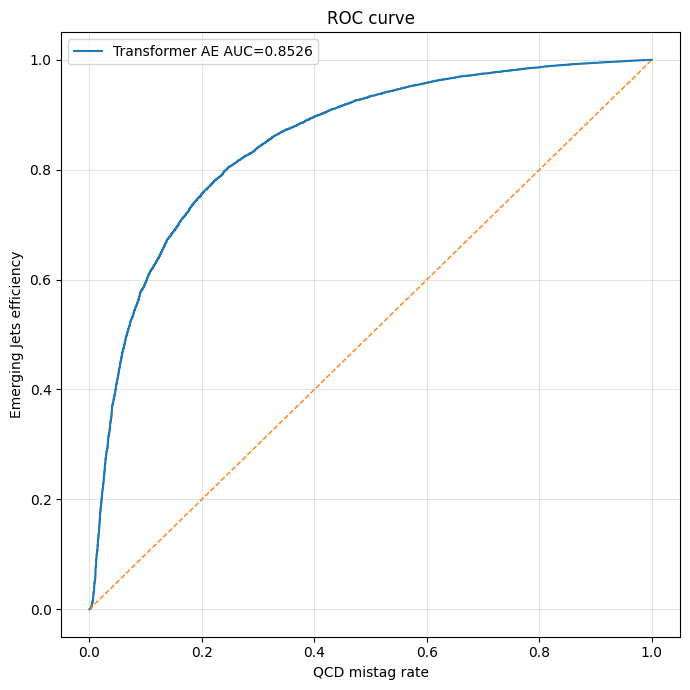

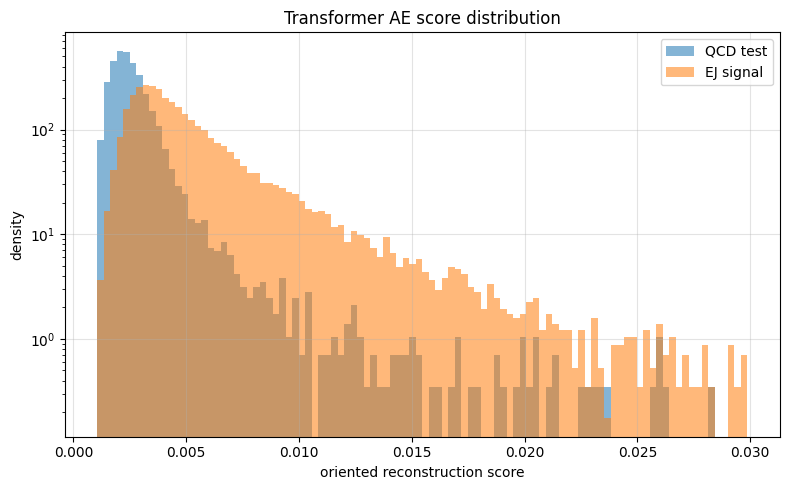

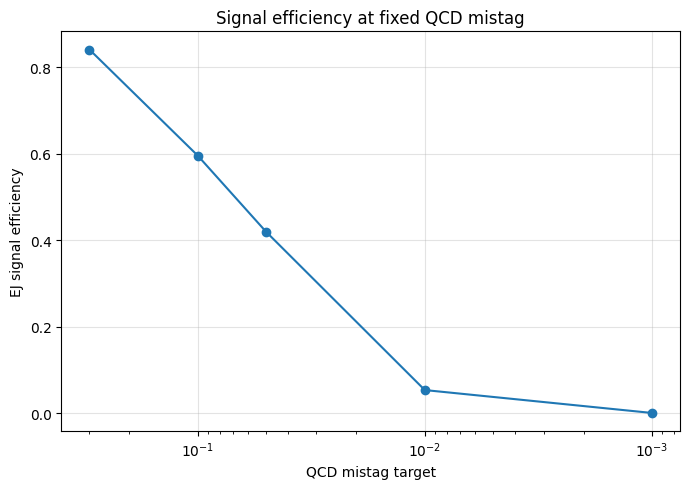

In [ ]:
# Plot delle metriche principali.
# Visualizzo ROC, distribuzioni degli score ed efficienze.
# Questi grafici sono quelli principali da mostrare nel report.
# La ROC riassume la separazione globale.
# La distribuzione degli score mostra visivamente la separazione QCD/segnale.
# L'efficienza a mistag fissato dice quanto segnale sopravvive a tagli stretti sul background.

bg_o = eval_main["bg_oriented"]
sig_o = eval_main["sig_oriented"]

plt.figure(figsize=(7, 7))
plt.plot(
    eval_main["fpr"],
    eval_main["tpr"],
    label=f"Transformer AE AUC={eval_main['best_auc']:.4f}",
)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("QCD mistag rate")
plt.ylabel("Emerging Jets efficiency")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_track_autoencoder_roc.png", dpi=200)
plt.show()

all_scores = np.concatenate([bg_o, sig_o])
lo = np.percentile(all_scores, 0.1)
hi = np.percentile(all_scores, 99.5)

plt.figure(figsize=(8, 5))
plt.hist(bg_o, bins=100, range=(lo, hi), density=True, alpha=0.55, label="QCD test")
plt.hist(sig_o, bins=100, range=(lo, hi), density=True, alpha=0.55, label="EJ signal")
plt.yscale("log")
plt.xlabel("oriented reconstruction score")
plt.ylabel("density")
plt.title("Transformer AE score distribution")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_track_autoencoder_score_distribution.png", dpi=200)
plt.show()

eff_df = eval_main["eff_table"]

plt.figure(figsize=(7, 5))
plt.plot(
    eff_df["mistag_target"],
    eff_df["signal_efficiency"],
    marker="o",
)
plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("QCD mistag target")
plt.ylabel("EJ signal efficiency")
plt.title("Signal efficiency at fixed QCD mistag")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_track_autoencoder_eff_vs_mistag.png", dpi=200)
plt.show()


## 19. SIC curve

Calcola la Significance Improvement Characteristic, cioè `SIC = efficienza del segnale / sqrt(efficienza del background)`.

In modo approssimato, questa quantità misura quanto il tagger può migliorare la significatività statistica di una ricerca. Un punto con SIC alta indica una soglia dello score dove il segnale viene mantenuto bene mentre il background viene ridotto molto.

La SIC è particolarmente utile perché l'AUC descrive la separazione globale, mentre la SIC evidenzia le regioni operative più interessanti per un'analisi collider.

Max SIC: 1.9438300318196564
QCD mistag at max SIC: 0.0649
Signal efficiency at max SIC: 0.4952
Threshold at max SIC: 0.004258895292878151
Saved: ..\outputs\transformer_track_autoencoder\transformer_track_autoencoder_sic_curve.csv


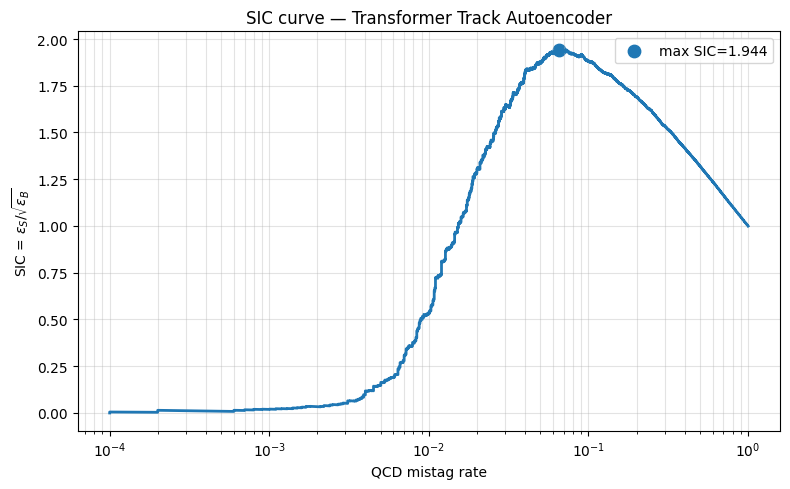

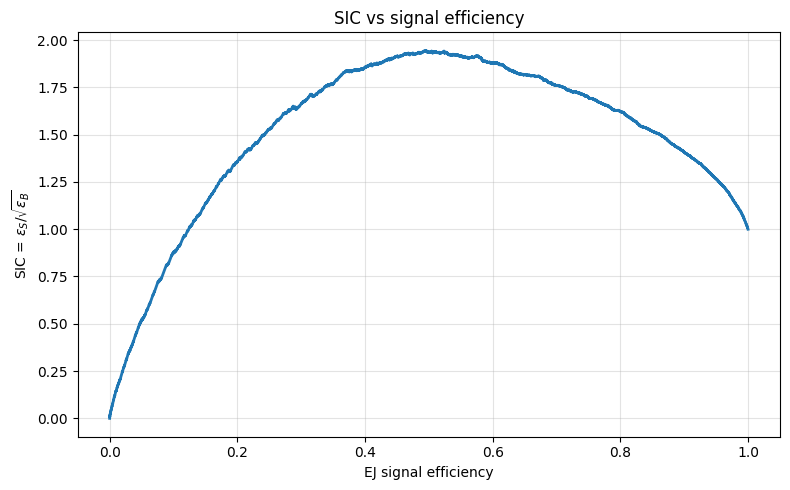

In [ ]:
# Calcolo la SIC curve.
# È una misura del miglioramento di significatività.
# Un AUC alto è buono, ma non dice direttamente quale taglio migliora di più
# la sensibilità dell'analisi. La SIC invece evidenzia il punto operativo migliore.
# Se il massimo della SIC cade a mistag molto basso, il modello è utile in regione di alta reiezione QCD.

# SIC = signal efficiency / sqrt(background efficiency).
# È utile perché mostra in quale regione di mistag il tagger dà il massimo guadagno di significatività.

fpr = np.asarray(eval_main["fpr"], dtype=np.float64)
tpr = np.asarray(eval_main["tpr"], dtype=np.float64)
thresholds = np.asarray(eval_main["thresholds"], dtype=np.float64)

valid = (fpr > 0) & np.isfinite(fpr) & np.isfinite(tpr)

sic_fpr = fpr[valid]
sic_tpr = tpr[valid]
sic_thresholds = thresholds[valid]
sic = sic_tpr / np.sqrt(sic_fpr)

finite_sic = np.isfinite(sic)

sic_fpr = sic_fpr[finite_sic]
sic_tpr = sic_tpr[finite_sic]
sic_thresholds = sic_thresholds[finite_sic]
sic = sic[finite_sic]

if len(sic) == 0:
    max_sic = np.nan
    mistag_at_max_sic = np.nan
    eff_at_max_sic = np.nan
    threshold_at_max_sic = np.nan
    print("[WARN] SIC non calcolabile.")

else:
    best_idx = int(np.argmax(sic))

    max_sic = float(sic[best_idx])
    mistag_at_max_sic = float(sic_fpr[best_idx])
    eff_at_max_sic = float(sic_tpr[best_idx])
    threshold_at_max_sic = float(sic_thresholds[best_idx])

    sic_df = pd.DataFrame({
        "qcd_mistag": sic_fpr,
        "signal_efficiency": sic_tpr,
        "sic": sic,
        "threshold": sic_thresholds,
    })

    sic_df.to_csv(
        OUTPUT_DIR / "transformer_track_autoencoder_sic_curve.csv",
        index=False,
    )

    print("Max SIC:", max_sic)
    print("QCD mistag at max SIC:", mistag_at_max_sic)
    print("Signal efficiency at max SIC:", eff_at_max_sic)
    print("Threshold at max SIC:", threshold_at_max_sic)
    print("Saved:", OUTPUT_DIR / "transformer_track_autoencoder_sic_curve.csv")

    plt.figure(figsize=(8, 5))
    plt.plot(sic_fpr, sic, linewidth=2)
    plt.scatter([mistag_at_max_sic], [max_sic], s=80, label=f"max SIC={max_sic:.3f}")
    plt.xscale("log")
    plt.xlabel("QCD mistag rate")
    plt.ylabel(r"SIC = $\epsilon_S / \sqrt{\epsilon_B}$")
    plt.title("SIC curve — Transformer Track Autoencoder")
    plt.legend()
    plt.grid(True, which="both", alpha=0.35)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "transformer_track_autoencoder_sic_curve.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(sic_tpr, sic, linewidth=2)
    plt.xlabel("EJ signal efficiency")
    plt.ylabel(r"SIC = $\epsilon_S / \sqrt{\epsilon_B}$")
    plt.title("SIC vs signal efficiency")
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "transformer_track_autoencoder_sic_vs_efficiency.png", dpi=200)
    plt.show()


## 20. Background consistency checks
Controlla che lo score non stia separando artificialmente diversi campioni QCD. Confronto QCD train, QCD validation e QCD test tra loro.

Idealmente questi AUC QCD-vs-QCD devono essere vicini a 0.5, perché sono tutti background. Se invece fossero molto alti, potrebbe esserci un problema di split, normalizzazione, domain shift o overfitting.

Questo controllo è importante per difendere il risultato: voglio che il modello separi Emerging Jets dal QCD, non due campioni QCD tra loro.

,comparison,auc,auc_inverted,best_auc
0,train QCD vs val QCD,0.503871,0.496129,0.503871
1,train QCD vs test QCD,0.506791,0.493209,0.506791
2,val QCD vs test QCD,0.502890,0.497110,0.502890


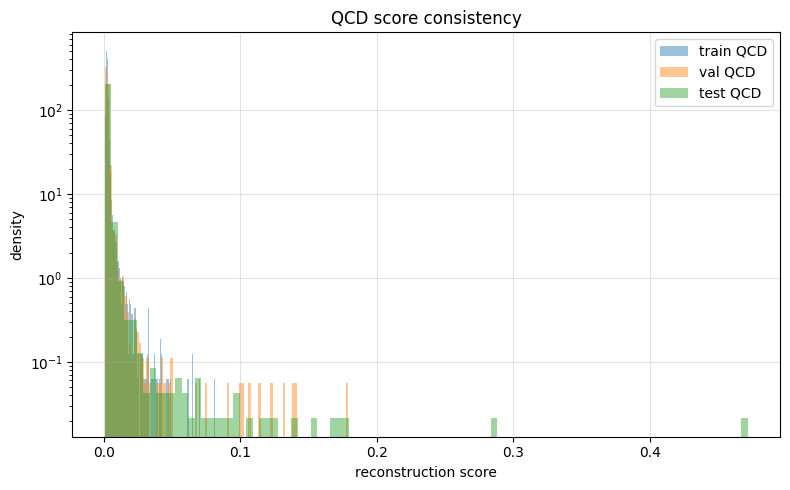

In [ ]:
# Controlli QCD-vs-QCD.
# Servono a verificare che lo score sia stabile sul background.
# Questo controllo serve a evitare una falsa separazione.
# Se train QCD, val QCD e test QCD sono separabili tra loro,
# il modello potrebbe aver imparato differenze tecniche tra split invece di fisica.
# Valori vicini a 0.5 sono rassicuranti.


def bg_vs_bg_auc(a, b, name_a, name_b):
    y = np.concatenate([
        np.zeros(len(a), dtype=np.int64),
        np.ones(len(b), dtype=np.int64),
    ])

    s = np.concatenate([a, b])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    return {
        "comparison": f"{name_a} vs {name_b}",
        "auc": auc,
        "auc_inverted": auc_inv,
        "best_auc": max(auc, auc_inv),
    }


bg_checks = pd.DataFrame([
    bg_vs_bg_auc(scores_train, scores_val, "train QCD", "val QCD"),
    bg_vs_bg_auc(scores_train, scores_bkg_test, "train QCD", "test QCD"),
    bg_vs_bg_auc(scores_val, scores_bkg_test, "val QCD", "test QCD"),
])

display(bg_checks)

plt.figure(figsize=(8, 5))
plt.hist(scores_train, bins=100, density=True, alpha=0.45, label="train QCD")
plt.hist(scores_val, bins=100, density=True, alpha=0.45, label="val QCD")
plt.hist(scores_bkg_test, bins=100, density=True, alpha=0.45, label="test QCD")
plt.yscale("log")
plt.xlabel("reconstruction score")
plt.ylabel("density")
plt.title("QCD score consistency")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_track_autoencoder_background_consistency.png", dpi=200)
plt.show()


## 21. Errori di ricostruzione per feature

Serve per interpretare il modello. Calcolo l'errore medio di ricostruzione separatamente per ogni feature, sia su QCD test sia su segnale.

Poi guardo quali feature hanno un errore molto più alto nel segnale rispetto al QCD. Questo aiuta a capire quali variabili fisiche contribuiscono allo score: per esempio feature legate a impatto trasverso, hit pattern o raggio del primo hit possono essere rilevanti per jet displaced.

Questa non è una feature importance supervisionata classica, ma una diagnostica dell'autoencoder: mostra quali feature il modello QCD-only ricostruisce peggio sugli Emerging Jets.

,feature_type,feature,qcd_test_mse,signal_mse,delta_signal_minus_qcd,ratio_signal_over_qcd
26,jet,Tau4_clusterSoftDrop,0.002755,0.022532,0.019777,8.177584
25,jet,Tau3_clusterSoftDrop,0.003330,0.018377,0.015047,5.518514
24,jet,Tau2_clusterSoftDrop,0.002715,0.009144,0.006430,3.368594
18,jet,mass,0.003691,0.009931,0.006240,2.690329
23,jet,Tau1_clusterSoftDrop,0.002380,0.008466,0.006086,3.556877
19,jet,energy,0.001664,0.004636,0.002972,2.786053
20,jet,Qw_clusterSoftDrop,0.005660,0.008420,0.002760,1.487625
16,jet,pt,0.001784,0.004532,0.002748,2.540345
17,jet,eta,0.001496,0.004107,0.002611,2.744629
1,track,d0_log1p,0.002410,0.003797,0.001387,1.575545


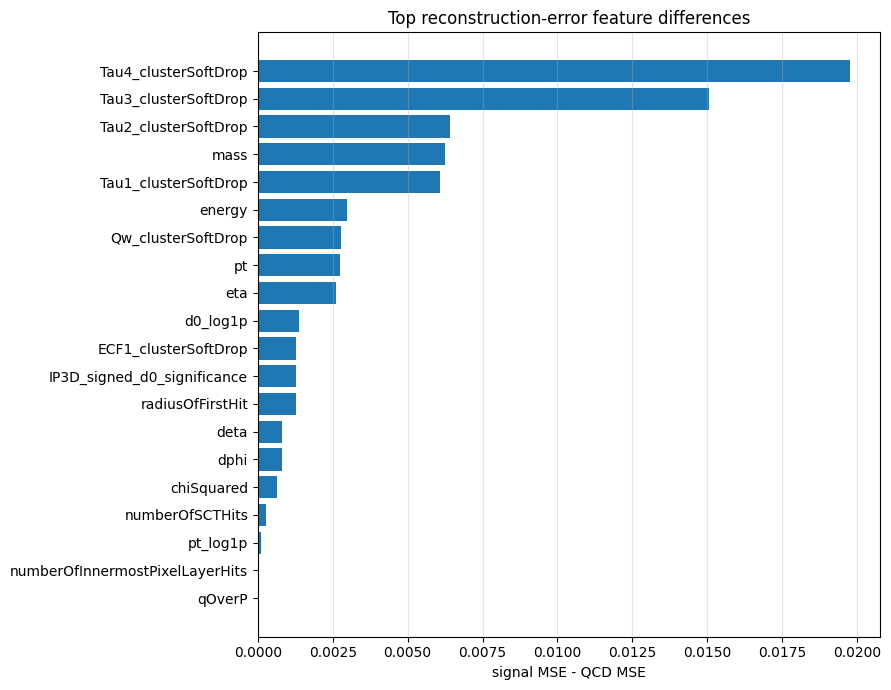

In [ ]:
# Errori di ricostruzione feature-by-feature.
# Uso questa parte per interpretare cosa il modello trova anomalo.
# Questa parte rende il modello interpretabile.
# Guardo quali feature vengono ricostruite peggio nel segnale rispetto al QCD.
# Per Emerging Jets mi aspetto possibili differenze su variabili di impatto,
# hit pattern, raggio del primo hit e variabili legate alla struttura delle tracce.


@torch.no_grad()
def feature_reconstruction_errors(model, X_jets, X_tracks, mask, batch_size=256):
    loader = make_loader(
        X_jets,
        X_tracks,
        mask,
        batch_size=batch_size,
        shuffle=False,
    )

    model.eval()

    track_sum = np.zeros(n_track_features, dtype=np.float64)
    track_count = np.zeros(n_track_features, dtype=np.float64)

    jet_sum = np.zeros(n_jet_features, dtype=np.float64)
    jet_count = 0

    for x_jets, x_tracks, m in loader:
        x_jets = x_jets.to(device)
        x_tracks = x_tracks.to(device)
        m = m.to(device)

        jet_reco, track_reco, _ = model(x_jets, x_tracks, m)

        mask_f = m.unsqueeze(-1).float()

        track_sq = ((track_reco - x_tracks) ** 2) * mask_f

        track_sum += track_sq.sum(dim=(0, 1)).detach().cpu().numpy()
        track_count += mask_f.sum(dim=(0, 1)).detach().cpu().numpy()

        if n_jet_features > 0:
            jet_sq = (jet_reco - x_jets) ** 2
            jet_sum += jet_sq.sum(dim=0).detach().cpu().numpy()
            jet_count += x_jets.shape[0]

    track_mean = track_sum / np.maximum(track_count, 1.0)

    if n_jet_features > 0:
        jet_mean = jet_sum / max(jet_count, 1)
    else:
        jet_mean = np.array([], dtype=np.float64)

    return track_mean, jet_mean


if DO_FEATURE_ERROR_TABLE:
    track_err_bkg, jet_err_bkg = feature_reconstruction_errors(
        model,
        X_jets_bkg_test,
        X_tracks_bkg_test,
        mask_bkg_test,
        batch_size=SCORE_BATCH_SIZE,
    )

    track_err_sig, jet_err_sig = feature_reconstruction_errors(
        model,
        X_jets_sig,
        X_tracks_sig,
        mask_sig,
        batch_size=SCORE_BATCH_SIZE,
    )

    track_feature_error_df = pd.DataFrame({
        "feature_type": "track",
        "feature": track_feature_names,
        "qcd_test_mse": track_err_bkg,
        "signal_mse": track_err_sig,
    })

    track_feature_error_df["delta_signal_minus_qcd"] = (
        track_feature_error_df["signal_mse"] - track_feature_error_df["qcd_test_mse"]
    )

    track_feature_error_df["ratio_signal_over_qcd"] = (
        track_feature_error_df["signal_mse"] / np.maximum(track_feature_error_df["qcd_test_mse"], 1e-12)
    )

    jet_feature_error_df = pd.DataFrame({
        "feature_type": "jet",
        "feature": jet_feature_names,
        "qcd_test_mse": jet_err_bkg,
        "signal_mse": jet_err_sig,
    })

    jet_feature_error_df["delta_signal_minus_qcd"] = (
        jet_feature_error_df["signal_mse"] - jet_feature_error_df["qcd_test_mse"]
    )

    jet_feature_error_df["ratio_signal_over_qcd"] = (
        jet_feature_error_df["signal_mse"] / np.maximum(jet_feature_error_df["qcd_test_mse"], 1e-12)
    )

    feature_error_df = pd.concat(
        [track_feature_error_df, jet_feature_error_df],
        axis=0,
        ignore_index=True,
    ).sort_values("delta_signal_minus_qcd", ascending=False)

    feature_error_df.to_csv(
        OUTPUT_DIR / "transformer_track_autoencoder_feature_reco_errors.csv",
        index=False,
    )

    display(feature_error_df.head(25))

    top = feature_error_df.head(20).iloc[::-1]

    plt.figure(figsize=(9, 7))
    plt.barh(top["feature"], top["delta_signal_minus_qcd"])
    plt.xlabel("signal MSE - QCD MSE")
    plt.title("Top reconstruction-error feature differences")
    plt.grid(True, axis="x", alpha=0.35)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "transformer_track_autoencoder_top_feature_errors.png", dpi=200)
    plt.show()

else:
    feature_error_df = pd.DataFrame()
    print("Feature error table disattivata.")


## 22. Permutation check

Verifica che il modello sia ragionevolmente invariante rispetto all'ordine delle tracce. Dal punto di vista fisico, un jet è un insieme di tracce: l'ordine con cui le tracce sono salvate nell'array non dovrebbe cambiare molto lo score.

Per testarlo, permuto casualmente le tracce di alcuni eventi e confronto lo score prima e dopo la permutazione. Idealmente la differenza media dovrebbe essere piccola.

Il Transformer contiene self-attention e pooling, quindi non dovrebbe dipendere fortemente dall'ordine, anche se non è matematicamente identico a una rete completamente permutation-invariant.

In [ ]:
# Controllo dell'invarianza rispetto alla permutazione delle tracce.
# L'ordine delle tracce non dovrebbe cambiare molto lo score.
# Questo controllo è importante perché le tracce non hanno un ordine fisico assoluto.
# Se permuto le tracce e lo score cambia molto, il modello sta usando informazioni
# spurie legate all'ordine nell'array. Una variazione piccola è invece coerente
# con una rappresentazione set-like del jet.

@torch.no_grad()
def permutation_score_check(model, X_jets, X_tracks, mask, n_samples=512):
    model.eval()

    n_samples = min(n_samples, X_jets.shape[0])

    Xj = torch.from_numpy(X_jets[:n_samples]).float().to(device)
    Xt = torch.from_numpy(X_tracks[:n_samples]).float().to(device)
    M = torch.from_numpy(mask[:n_samples]).bool().to(device)

    B, N, F = Xt.shape

    perm = torch.stack(
        [torch.randperm(N, device=device) for _ in range(B)],
        dim=0,
    )

    perm_exp = perm.unsqueeze(-1).expand(B, N, F)

    Xt_perm = torch.gather(Xt, dim=1, index=perm_exp)
    M_perm = torch.gather(M, dim=1, index=perm)

    jet_reco, track_reco, _ = model(Xj, Xt, M)
    jet_reco_p, track_reco_p, _ = model(Xj, Xt_perm, M_perm)

    def score_tensor(xj, xt, m, jr, tr):
        mask_f = m.unsqueeze(-1).float()
        track_sq = (tr - xt) ** 2
        track_event = (track_sq * mask_f).sum(dim=(1, 2)) / (
            mask_f.sum(dim=(1, 2)) * xt.shape[-1]
        ).clamp_min(1.0)

        jet_event = torch.mean((jr - xj) ** 2, dim=1)

        return track_event + JET_SCORE_WEIGHT * jet_event

    s = score_tensor(Xj, Xt, M, jet_reco, track_reco)
    s_p = score_tensor(Xj, Xt_perm, M_perm, jet_reco_p, track_reco_p)

    return {
        "mean_abs_delta_score": float(torch.mean(torch.abs(s - s_p)).detach().cpu()),
        "max_abs_delta_score": float(torch.max(torch.abs(s - s_p)).detach().cpu()),
    }


if DO_PERMUTATION_CHECK:
    perm_check = permutation_score_check(
        model,
        X_jets_bkg_test,
        X_tracks_bkg_test,
        mask_bkg_test,
        n_samples=512,
    )

    print("Permutation score check:")
    print(perm_check)

else:
    perm_check = {
        "mean_abs_delta_score": np.nan,
        "max_abs_delta_score": np.nan,
    }


Permutation score check:
{'mean_abs_delta_score': 1.7221282178070396e-09, 'max_abs_delta_score': 1.1920928955078125e-07}


## 23. Salvataggio finale
Salva tutti gli output importanti del notebook: modello PyTorch, configurazione, score, metriche, background checks e summary.

Il file `.npz` con gli score è quello più utile per il notebook di valutazione finale, perché contiene score QCD, score segnale, curve ROC, SIC e rappresentazioni latenti.

Salvare anche JSON e CSV rende il run più riproducibile: posso recuperare in seguito quale architettura, learning rate, batch size e parametri di denoising sono stati usati.

In [ ]:
# Salvo modello, score, metriche e configurazione.
# Questi file verranno usati anche nella valutazione finale.
# Salvo tutto quello che serve per riprodurre e confrontare il run.
# Il file scores.npz è quello da usare nella valutazione finale multi-modello.
# Il config.json serve per ricordare esattamente quale architettura e quali iperparametri
# hanno prodotto questi risultati.


results_summary = {
    "model": "Transformer Track Autoencoder",
    "score": "masked reconstruction error",
    "auc": float(eval_main["auc"]),
    "auc_inverted": float(eval_main["auc_inverted"]),
    "best_auc": float(eval_main["best_auc"]),
    "flipped": bool(eval_main["flipped"]),
    "max_sic": float(max_sic),
    "mistag_at_max_sic": float(mistag_at_max_sic),
    "eff_at_max_sic": float(eff_at_max_sic),
    "threshold_at_max_sic": float(threshold_at_max_sic),
    "n_train": int(len(X_jets_train)),
    "n_val": int(len(X_jets_val)),
    "n_bkg_test": int(len(X_jets_bkg_test)),
    "n_signal": int(len(X_jets_sig)),
    "n_track_features": int(n_track_features),
    "n_jet_features": int(n_jet_features),
    "max_tracks": int(max_tracks),
    "d_model": int(D_MODEL),
    "n_heads": int(N_HEADS),
    "n_layers": int(N_LAYERS),
    "dim_feedforward": int(DIM_FEEDFORWARD),
    "latent_dim": int(LATENT_DIM),
    "dropout": float(DROPOUT),
    "learning_rate": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "noise_std": float(NOISE_STD),
    "feature_drop_prob": float(FEATURE_DROP_PROB),
    "jet_score_weight": float(JET_SCORE_WEIGHT),
    "hparam_tuning_used": bool(RUN_HPARAM_TUNING),
    "hparam_selection_score": float(BEST_CONFIG.get("selection_score", np.nan)),
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
    "permutation_mean_abs_delta_score": float(perm_check["mean_abs_delta_score"]),
    "permutation_max_abs_delta_score": float(perm_check["max_abs_delta_score"]),
}

with open(OUTPUT_DIR / "transformer_track_autoencoder_config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            **results_summary,
            "processed_path": str(PROCESSED_PATH),
            "jet_feature_names": jet_feature_names,
            "track_feature_names": track_feature_names,
            "best_config": {
                k: (
                    float(v) if isinstance(v, np.floating)
                    else int(v) if isinstance(v, np.integer)
                    else v
                )
                for k, v in BEST_CONFIG.items()
            },
        },
        f,
        indent=2,
    )

eval_main["eff_table"].to_csv(
    OUTPUT_DIR / "transformer_track_autoencoder_results.csv",
    index=False,
)

bg_checks.to_csv(
    OUTPUT_DIR / "transformer_track_autoencoder_background_checks.csv",
    index=False,
)

pd.DataFrame([results_summary]).to_csv(
    OUTPUT_DIR / "transformer_track_autoencoder_summary.csv",
    index=False,
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": results_summary,
        "best_config": BEST_CONFIG,
        "jet_feature_names": jet_feature_names,
        "track_feature_names": track_feature_names,
    },
    OUTPUT_DIR / "transformer_track_autoencoder_model.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "transformer_track_autoencoder_scores.npz",
    scores_train=scores_train,
    scores_val=scores_val,
    scores_bkg_test=scores_bkg_test,
    scores_sig=scores_sig,
    scores_train_track=scores_train_dict["track"],
    scores_val_track=scores_val_dict["track"],
    scores_bkg_test_track=scores_bkg_test_dict["track"],
    scores_sig_track=scores_sig_dict["track"],
    scores_train_jet=scores_train_dict["jet"],
    scores_val_jet=scores_val_dict["jet"],
    scores_bkg_test_jet=scores_bkg_test_dict["jet"],
    scores_sig_jet=scores_sig_dict["jet"],
    Z_train=Z_train,
    Z_val=Z_val,
    Z_bkg_test=Z_bkg_test,
    Z_sig=Z_sig,
    bg_oriented=eval_main["bg_oriented"],
    sig_oriented=eval_main["sig_oriented"],
    fpr=eval_main["fpr"],
    tpr=eval_main["tpr"],
    thresholds=eval_main["thresholds"],
    sic_fpr=sic_fpr if "sic_fpr" in globals() else np.array([], dtype=np.float32),
    sic_tpr=sic_tpr if "sic_tpr" in globals() else np.array([], dtype=np.float32),
    sic=sic if "sic" in globals() else np.array([], dtype=np.float32),
    max_sic=np.array(max_sic, dtype=np.float32),
    auc=np.array(eval_main["auc"], dtype=np.float32),
    auc_inverted=np.array(eval_main["auc_inverted"], dtype=np.float32),
    best_auc=np.array(eval_main["best_auc"], dtype=np.float32),
    jet_feature_names=np.array(jet_feature_names, dtype=object),
    track_feature_names=np.array(track_feature_names, dtype=object),
)

print("Saved:")
print(OUTPUT_DIR / "transformer_track_autoencoder_model.pt")
print(OUTPUT_DIR / "transformer_track_autoencoder_scores.npz")
print(OUTPUT_DIR / "transformer_track_autoencoder_results.csv")
print(OUTPUT_DIR / "transformer_track_autoencoder_background_checks.csv")
print(OUTPUT_DIR / "transformer_track_autoencoder_config.json")
print(OUTPUT_DIR / "transformer_track_autoencoder_summary.csv")
print("plots:", PLOTS_DIR)


Saved:
..\outputs\transformer_track_autoencoder\transformer_track_autoencoder_model.pt
..\outputs\transformer_track_autoencoder\transformer_track_autoencoder_scores.npz
..\outputs\transformer_track_autoencoder\transformer_track_autoencoder_results.csv
..\outputs\transformer_track_autoencoder\transformer_track_autoencoder_background_checks.csv
..\outputs\transformer_track_autoencoder\transformer_track_autoencoder_config.json
..\outputs\transformer_track_autoencoder\transformer_track_autoencoder_summary.csv
plots: ..\outputs\transformer_track_autoencoder\plots
